# 1. Data Understanding

## Install

In [160]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from itables import show

In [161]:
import os

# Current working directory
print("CWD:", os.getcwd())

# List top-level files/folders
print(os.listdir("."))

CWD: e:\COOLYEAH\skripsi\project-code
['.env', '.git', '.gitattributes', '.gitignore', '.venv', '1_data_understanding.ipynb', '2_a_data_cleaning.ipynb', '2_b_1_data_enrichment.ipynb', '2_b_2_after_enrichment.ipynb', '2_b_data_enrichment.py', '2_c_Embedding.ipynb', '2_d_Sequence.ipynb', '3_modelling.ipynb', 'base_model.ipynb', 'data', 'enrichment_log', 'google_books_cache.db', 'google_books_cache_v3.db', 'list_1.0.0.txt', 'llm_sasrec.ipynb', 'requirements.txt', 'sample_book_data']


# Data Buku

## Load

In [162]:
file_path = "data/raw/book_data.csv"
upn_books = pd.read_csv(file_path, low_memory=False, delimiter=';')

In [163]:
upn_books.info()

<class 'pandas.DataFrame'>
RangeIndex: 55160 entries, 0 to 55159
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   title           55153 non-null  str  
 1   gmd_name        55157 non-null  str  
 2   edition         9127 non-null   str  
 3   isbn_issn       34946 non-null  str  
 4   publisher_name  54070 non-null  str  
 5   publish_year    54253 non-null  str  
 6   collation       42145 non-null  str  
 7   series_title    15 non-null     str  
 8   call_number     46445 non-null  str  
 9   language_name   48533 non-null  str  
 10  place_name      33749 non-null  str  
 11  classification  32947 non-null  str  
 12  notes           1875 non-null   str  
 13  image           1446 non-null   str  
 14  sor             798 non-null    str  
 15  authors         52183 non-null  str  
 16  topics          24177 non-null  str  
 17  item_code       53042 non-null  str  
 18  Unnamed: 18     1 non-null      str  

In [164]:
upn_books.sample(5)

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
42080,Simple English Conversation: Percakapan mudah ...,Text,NaN,9789793931779,Cakrawala Ilmu,2015,181 hlm.; 21 cm,NaN,420 IMA s,Indonesia,Yogyakarta,NaN,NaN,NaN,NaN,<IMAM Baehaqi>,<BAHASA INGGRIS>,<91684101><91684102>,NaN
31606,Kapitalisme yang Layak : Suatu cetak biru refo...,Text,NaN,978 0 7453 3109 6,Friedrich-Ebert-Stiftung Kantor Perwakilan Ind...,2019,"xx, 229 p.; ind.; 23 cm.",NaN,330.12 SEB k,Indonesia,Jakarta,330.12,NaN,NaN,NaN,"<Dullien, Sebastian>",<CAPITALISM--ECONOMIC ASPECTS>,<923021784>,NaN
4256,Gendering women: identity and mental wellbeing...,Electronic Resource,NaN,9781847426789,Bristol University Press (BUP),2014,281,NaN,305.4,English,NaN,305.4,NaN,NaN,NaN,"<Clisby, Suzanne;Holdsworth, Julia>",NaN,<614521>,NaN
48056,Warisan nehru,Tesis,text,979-420-252-5,Gadjah Mada University Press,1984,"xii, 96 p.; 21 cm.",NaN,923.1,Indonesia,Yogyakarta,NaN,NaN,NaN,NaN,NaN,<Head of state - biography>,<90717401>,NaN
11157,"Accessing technical education in modern Japan,...",Electronic Resource,NaN,9781912961269,Amsterdam University Press (AUP),2022,504,NaN,NaN,English,NaN,NaN,NaN,NaN,NaN,"<Pauer, Erich;Mathias, Regine>",NaN,<613186>,NaN


## Data Checking

### Format Data

In [165]:
upn_books.info()

<class 'pandas.DataFrame'>
RangeIndex: 55160 entries, 0 to 55159
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   title           55153 non-null  str  
 1   gmd_name        55157 non-null  str  
 2   edition         9127 non-null   str  
 3   isbn_issn       34946 non-null  str  
 4   publisher_name  54070 non-null  str  
 5   publish_year    54253 non-null  str  
 6   collation       42145 non-null  str  
 7   series_title    15 non-null     str  
 8   call_number     46445 non-null  str  
 9   language_name   48533 non-null  str  
 10  place_name      33749 non-null  str  
 11  classification  32947 non-null  str  
 12  notes           1875 non-null   str  
 13  image           1446 non-null   str  
 14  sor             798 non-null    str  
 15  authors         52183 non-null  str  
 16  topics          24177 non-null  str  
 17  item_code       53042 non-null  str  
 18  Unnamed: 18     1 non-null      str  

In [166]:
upn_books.dtypes

title             str
gmd_name          str
edition           str
isbn_issn         str
publisher_name    str
publish_year      str
collation         str
series_title      str
call_number       str
language_name     str
place_name        str
classification    str
notes             str
image             str
sor               str
authors           str
topics            str
item_code         str
Unnamed: 18       str
dtype: object

### Duplikasi

In [167]:
upn_books.duplicated().sum()

np.int64(3)

In [168]:
upn_books['title'].nunique()

45607

In [169]:
upn_books.duplicated(subset=['title', 'authors', 'isbn_issn']).sum()

np.int64(5875)

In [170]:
upn_books.duplicated(subset=['title', 'authors']).sum()

np.int64(6494)

In [171]:
title_authors_duplicates_mask = upn_books.duplicated(subset=['title', 'authors'], keep=False)
title_authors_duplicates = upn_books[title_authors_duplicates_mask]
show(title_authors_duplicates.sort_values(by=['title', 'authors']))

Loading ITables v2.7.0 from the internet... (need help?)


In [172]:
all_duplicates_mask = upn_books.duplicated(subset=['title', 'authors', 'isbn_issn'], keep=False)
all_duplicates = upn_books[all_duplicates_mask]
show(all_duplicates.sort_values(by=['title', 'authors']))

Loading ITables v2.7.0 from the internet... (need help?)


### Missing Values (kelengkapan dan null data)

In [173]:
upn_books.isnull().sum()

title                 7
gmd_name              3
edition           46033
isbn_issn         20214
publisher_name     1090
publish_year        907
collation         13015
series_title      55145
call_number        8715
language_name      6627
place_name        21411
classification    22213
notes             53285
image             53714
sor               54362
authors            2977
topics            30983
item_code          2118
Unnamed: 18       55159
dtype: int64

thats a bit much of missing value

In [174]:
show(upn_books[upn_books['title'].isna()])

Loading ITables v2.7.0 from the internet... (need help?)


In [175]:
show(upn_books[upn_books['authors'].isna()])

Loading ITables v2.7.0 from the internet... (need help?)


In [176]:
show(upn_books[upn_books['isbn_issn'].isna()])

Loading ITables v2.7.0 from the internet... (need help?)


In [177]:
show(upn_books[upn_books['item_code'].isna()])

Loading ITables v2.7.0 from the internet... (need help?)


Tesis ini kok isinya kayak buku yang di rak gaboleh dipinjem ya?

## Eksploration

### Sor

In [178]:
show(upn_books['sor'].value_counts())

Loading ITables v2.7.0 from the internet... (need help?)


nih tuh yaudah

### gmd

In [179]:
upn_books['gmd_name'].value_counts()

gmd_name
Text                        25200
Electronic Resource         10186
Electronic Resources         9997
Tesis                        9241
Skripsi                       465
Art Original                   55
CD-ROM                          6
print                           3
Equipment                       2
Multimedia                      1
Human-Centered Computing        1
Name: count, dtype: int64

In [180]:
upn_books[upn_books['gmd_name'] == 'Electronic Resource']['classification'].value_counts()

classification
NONE                              666
194                                88
006.3                              50
005                                46
005.1                              44
                                 ... 
Desktop publishing                  1
Environmental management Pages      1
Food security and supply            1
Society and culture: general        1
302.3                               1
Name: count, Length: 3737, dtype: int64

In [181]:
upn_books[upn_books['gmd_name'] == 'Electronic Resources']['classification'].value_counts()

classification
301        82
006.3      67
616.89     59
005.1      58
005        57
           ..
657.028     1
657.42      1
532         1
530.11      1
004.68      1
Name: count, Length: 2652, dtype: int64

In [182]:
upn_books[upn_books['gmd_name'] == 'Equipment']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
24392,Nonequilibrium Quantum Field Theory,Equipment,NaN,NaN,Cambridge University Press,2022,NaN,NaN,NaN,NaN,NaN,NONE,NaN,NaN,NaN,<Esteban A. Calzetta>,<Nanoscience and Mesoscopic>,<600009>,NaN
24417,Big Business and the Crisis of German Democracy,Equipment,NaN,NaN,Cambridge University Press,2023,NaN,NaN,NaN,NaN,NaN,NONE,NaN,NaN,NaN,<Adam Bisno>,<Twentieth Century European History>,NaN,NaN


In [183]:
show(upn_books[upn_books['gmd_name'] == 'Tesis'])

Loading ITables v2.7.0 from the internet... (need help?)


In [184]:
show(upn_books[upn_books['gmd_name'] == 'Human Centered Computing'])

Loading ITables v2.7.0 from the internet... (need help?)


In [185]:
upn_books.loc[upn_books['gmd_name'] == 'Electronic Resources', 'gmd_name'] = 'Electronic Resource'
upn_books.loc[upn_books['gmd_name'] == 'print', 'gmd_name'] = 'Text'
upn_books.loc[upn_books['gmd_name'] == 'Tesis', 'gmd_name'] = 'Text'
upn_books.loc[upn_books['gmd_name'] == 'Skripsi', 'gmd_name'] = 'Text'
upn_books['gmd_name'].value_counts()

gmd_name
Text                        34909
Electronic Resource         20183
Art Original                   55
CD-ROM                          6
Equipment                       2
Multimedia                      1
Human-Centered Computing        1
Name: count, dtype: int64

Text(0.5, 0, 'GMD Name')

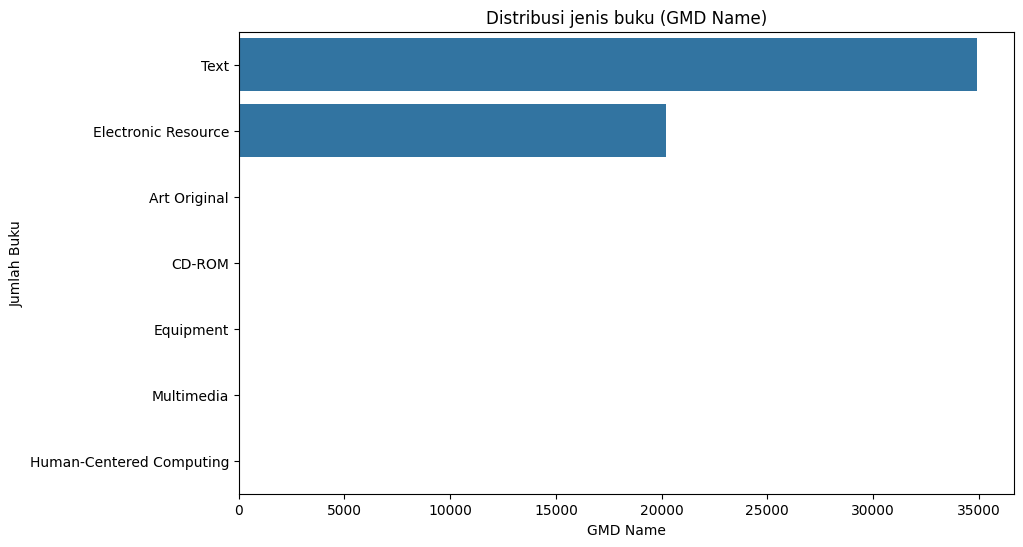

In [186]:
plt.figure(figsize=(10, 6))
sns.countplot(data=upn_books, y='gmd_name', order=upn_books['gmd_name'].value_counts().index)
plt.title('Distribusi jenis buku (GMD Name)')
plt.ylabel('Jumlah Buku')
plt.xlabel('GMD Name')

### classification

#### checkkk

In [187]:
show(upn_books['classification'].value_counts().sort_values(ascending=False))

Loading ITables v2.7.0 from the internet... (need help?)


In [188]:
upn_books['classification'].value_counts().sort_values(ascending=False).head(15)

classification
-SKRIPSI        6785
NONE            3086
SKRIPSI         1248
TUGAS AKHIR     1000
658              745
657              470
302.2            430
TESIS            233
-TUGAS AKHIR     213
001.42           179
659.2            174
301              138
70               130
658.8            121
302.23           119
Name: count, dtype: int64

In [189]:
upn_books['classification'].value_counts().sort_values(ascending=False).tail(15)

classification
0053/JM/2023             1
0052/JM/2023             1
0016/JM/2023             1
0051/JM/2023             1
346.004                  1
355.033                  1
302.23092                1
302.230 973              1
SKRIPSI IKOM             1
711.78                   1
TESIS-MAK                1
Skripsi ADNI 009/2023    1
Tesis MIL 001/2022       1
TESIS IL                 1
S-ADBIS                  1
Name: count, dtype: int64

Text(0.5, 0, 'Klasifikasi')

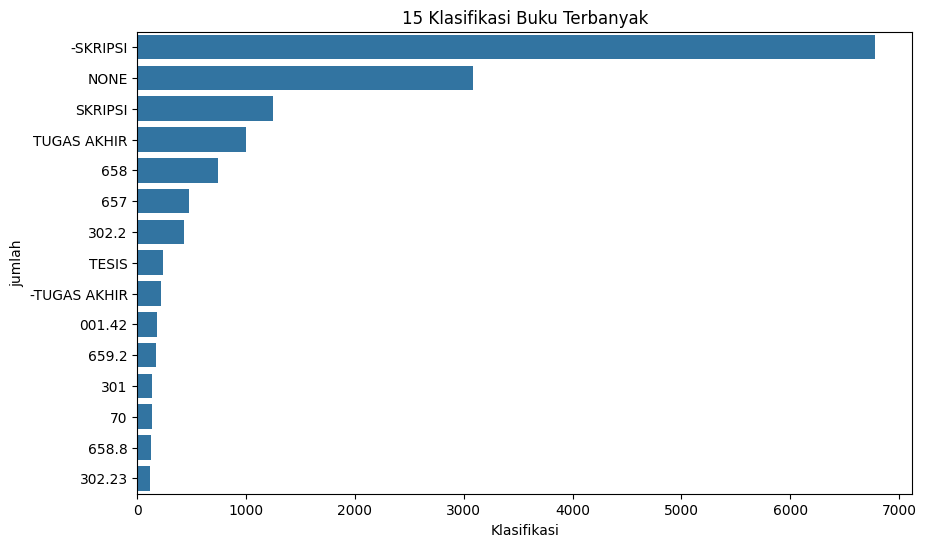

In [190]:
plt.figure(figsize=(10, 6))
sns.countplot(data=upn_books, y='classification', order=upn_books['classification'].value_counts().head(15).index)
plt.title('15 Klasifikasi Buku Terbanyak')
plt.ylabel('jumlah')
plt.xlabel('Klasifikasi')

In [191]:
upn_books[upn_books['classification'] == 'NONE']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
163,Edible Coatings And Films To Improve Food Quality,Text,NaN,1-56676-113-1,CRC Press,2002,"ix, 357p; 30cm.",NaN,664.068 5 EDI e,English,London,NONE,NaN,NaN,NaN,"<Krochta, John M.><Baldwin, Elizabeth A.><Nisp...",<Food industry>,<91149401>,NaN
166,Starch Hydrolysis Products: Worlwide Technolog...,Text,NaN,1-56081-055-6,VCH Publisher,1992,"xi, 637p; 24cm.",NaN,664.2 STA s,Indonesia,New York,NONE,NaN,NaN,NaN,"<Schenck, Fred W.><Hebeda, Ronald E.>",<STARCH>,<91136301>,NaN
300,"PENGARUH INKLUSI KEUANGAN, GAYA HIDUP, DAN PER...",Text,NaN,NaN,FEB UPN Veteran Jatim,2025,NaN,NaN,NaN,Indonesia,Surabaya,NONE,NaN,NaN,NaN,<ZULFIKAR KHUSNUL GHINA RIZKY>,<EKONOMI PEMBANGUNAN>,<825120217>,NaN
398,Vogel buku teks analisis anorganik kualitatif ...,Text,text,NaN,Kalman Media Pusaka,1990,"xv, 315p.; ill.; ind.; 22cm.",NaN,546 VOG v,Indonesia,Jakarta,NONE,NaN,NaN,NaN,"<Svehla, G.>","<Chemistry, Inorganic-Qualitative analysis>",<90388701><90388702><90388703><90388704>,NaN
419,Ice cream,Text,5th edition,0-8342-1917-4,An Aspen Publishing,2000,"xi, 371 p.; ind.; 23 cm.",NaN,641.862 MAR i,Indonesia,New York,NONE,NaN,NaN,NaN,"<Marshall, Robert T.><Arbuckle, W. S.>","<ICE CREAM, ICES>",<91147901><91174301>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51765,Combustion theory: the fundamental theory of c...,Text,text,NaN,Addison Wesley Publishing,1964,"xvi, 447p.; ill.; ind.; 23 cm.",NaN,541.361,Indonesia,London,NONE,NaN,NaN,NaN,"<Williams, Forman A.>",<Combustion>,<90210501>,NaN
51766,Chemical background for the biological sciences,Text,text,NaN,Prentice Hall of India Private Limited,1969,"viii, 152p.; ill.; ind.; 23 cm.",NaN,540,Indonesia,New Delhi,NONE,NaN,NaN,NaN,"<White, Emil H.>",<Biological chemistry>,NaN,NaN
55076,Perilaku organisasi buku satu,Text,NaN,979-691-142-6,Salemba Empat,2003,"xxi, 462 p.; ill.; 26 cm.",NaN,302.35,Indonesia,Jakarta,NONE,NaN,NaN,NaN,"<Kreitner, Robert>",<Organizational Bihavior>,<90000701><90000703>,NaN
55077,Indonesian highway capacity manual (HCM),Text,NaN,NaN,Directorate General Bina Marga,1997,"v, ca. 150 p.; ill.; 26 cm.",NaN,388.31,Indonesia,Jakarta,NONE,NaN,NaN,NaN,<Indonesia. Directorate General Bina Marga. Di...,"<TRANSPORTATION, AUTOMATIVE>",<90000801><90000802><90000803>,NaN


In [192]:
upn_books[upn_books['classification'] == '658']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
1,"Pemasaran jasa,manusia,teknologi,strategi pers...",Text,"e7,b1",978-979-099-474-4,Erlangga,2010,"xvii,442 hal,26 cm",NaN,658CHR,Indonesia,Jakarta,658,NaN,NaN,NaN,<Christopher lovelock>,<EKONOMI>,<FEB90003219>,NaN
2,"Pemasaran jasa,manusia,teknologi,strategi",Text,"e7,b2",978-602-241-124-6,Erlangga,2010,"xvi,272 hal,26 cm",NaN,658CHR,Indonesia,Jakarta,658,NaN,NaN,NaN,"<Lovelock, Christopher H.>",<EKONOMI>,<FEB90003218>,NaN
72,PERILAKU KONSUMEN,Text,kelima,979-688-317-1,PT PENERBIT AERLANGGA,2002,"2 : 17,5 x 25 cm",NaN,658 JOHN.p,Indonesia,Jakarta,658,NaN,NaN,NaN,<JOHN C. MOWEN><Michael Minor>,<PERILAKU>,<FP000003>,NaN
301,Manajemen Operasional,Text,1,978-602-97912-2-8,PT Buku Seru,2011,"viii,128 hal,26 cm",NaN,658DAN,Indonesia,Yogyakarta,658,NaN,NaN,NaN,<Danang Sunyoto>,<EKONOMI>,<FEB90003213>,NaN
5038,The logic of professionalism: work and managem...,Electronic Resource,NaN,9781529206098,Bristol University Press (BUP),2021,164,NaN,658,English,NaN,658,NaN,NaN,NaN,"<Alvehus, Johan>",NaN,<615325>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37948,teori komunikasi organisasi,Text,NaN,979-526-704-3,Bumi Aksara,2015,"215hm,26cm",NaN,658 sis p,Indonesia,Jakarta,658,NaN,NaN,NaN,<Siswanto>,<PENGANTAR MANAJEMEN>,<0490404001>,NaN
38015,Teori Ketahanan Nasiona,Text,NaN,978-979-29-5348-0,Andi,2016,"148hm,23cm",NaN,658 kar m,Indonesia,Yogyakarta,658,NaN,NaN,NaN,<KARYOTO>,<DASAR-DASAR MANAJEMEN>,<0490410701>,NaN
38119,Undang-Undang Otonomi 2004,Text,NaN,978-979-076-507-8,[s.n],2015,"207 hm,24CM",NaN,658 YUS,Indonesia,BANDUNG,658,NaN,NaN,NaN,<yusuf zaina abidin>,NaN,<0490421101>,NaN
38123,uNDANG-UNDANG KEPEGAWAIAN,Text,NaN,978-602-70569-1-6,MEDIA TERA,2015,"182hm,20CM",NaN,658 AND P,Indonesia,Yogyakarta,658,NaN,NaN,NaN,<KEPUTUSAN pRESIDEN>,<PENGANTAR MANAJEMEN 3 IN 1>,<0490421501>,NaN


In [193]:
upn_books[upn_books['classification'].str.contains('majalah', case=False, na=False)]

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
26720,UNESA ; CERITA INSPIRATIF KAMPUS MENGAJAR DI U...,Text,Nomor: 190 Tahun XXV - Juni 2024,1411 - 397X,Humas Universitas Negeri Surabaya,2024,NaN,NaN,Majalah 0073/2024,NaN,Surabaya,-Majalah,NaN,NaN,VINDA MAYA SETIANINGRUM,NaN,NaN,<524020073>,NaN
26721,MIMBAR LEGISLATIF ; DEWAN PERWAKILAN RAKYAT DA...,Text,NaN,NaN,DPRD Jawa Timur,2023,NaN,NaN,Majalah 0064/2024,Indonesia,Surabaya,-Majalah,NaN,NaN,NaN,NaN,NaN,<524020064>,NaN
26726,Prasetya East ; Infrastruktur Perhubungan Duku...,Text,September 2024,2085-3998,Biro Administrasi Pimpinan,2024,NaN,NaN,Majalah 0068/2024,NaN,Surabaya,-Majalah,NaN,NaN,"Pulung Chausar, Zainal Muttaqin",NaN,NaN,<524020068>,NaN
26727,Prasetya East ; Infrastruktur Perhubungan Duku...,Text,September 2024,2085-3998,Biro Administrasi Pimpinan,2024,NaN,NaN,Majalah 0067/2024,NaN,Surabaya,-Majalah,NaN,NaN,"Pulung Chausar, Zainal Muttaqin",NaN,NaN,<524020067>,NaN
26728,Prasetya East ; Infrastruktur Perhubungan Duku...,Text,September 2024,2085-3998,Biro Administrasi Pimpinan,2024,NaN,NaN,Majalah 0066/2024,NaN,Surabaya,-Majalah,NaN,NaN,"Pulung Chausar, Zainal Muttaqin",NaN,NaN,<524020066>,NaN
26729,CHENG HOO ; ERI AJAK WARGA JAGA SEMANGAT DAN ...,Text,NaN,NaN,Alm. Sukardi (Wen Jing Zeng),2024,NaN,NaN,Majalah 0065/2024,NaN,Surabaya,-Majalah,NaN,NaN,HMY Bambang Sujanto,NaN,NaN,<524020065>,NaN
26732,MIMBAR LEGISLATIF ; DEWAN PERWAKILAN RAKYAT DA...,Text,NaN,NaN,DPRD Jawa Timur,2023,NaN,NaN,Majalah 0063/2024,NaN,Surabaya,-MAJALAH,NaN,NaN,NaN,NaN,NaN,<524020063>,NaN
26736,UNESA ; PROGRAM MBKM PROYEK KEMANUSIAAN DI MAL...,Text,NaN,1411 - 397X,Humas Universitas Negeri Surabaya,2024,NaN,NaN,MAJALAH 0062/2024,NaN,Surabaya,-MAJALAH,NaN,NaN,VINDA MAYA SETIANINGRUM,NaN,NaN,<524020062>,NaN
26738,UNESA ; KISAH INSPIRATIF MAHASISWA PROGRAM MBK...,Text,NaN,1411 - 397X,Humas Universitas Negeri Surabaya,2024,NaN,NaN,MAJALAH 0061/2024,NaN,NaN,-MAJALAH,NaN,NaN,VINDA MAYA SETIANINGRUM,NaN,NaN,<524020061>,NaN
26742,Prasetya East ; Jatim Menuju Merdeka dari Kemi...,Text,NaN,2085-3998,Biro Administrasi Pimpinan,2024,NaN,NaN,Majalah 0059/2024,NaN,Surabaya,-Majalah,NaN,NaN,NaN,NaN,NaN,<524020059>,NaN


In [194]:
upn_books[upn_books['classification'].str.contains('SKRIPSI', case=False, na=False)]

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
0,Pengaruh Environmental Social and Governance (...,Text,NaN,NaN,FAKULTAS EKONOMI BISNIS UPN JATIM,2024,NaN,NaN,SKRIPSI EA 178/2024,Indonesia,Surabaya,-SKRIPSI,NaN,NaN,NaN,"<Pramudita, Nuril Ade>",NaN,<824130178>,NaN
3,PENGARUH DURASI PENGOPERASIAN MEMBRAN PVC-TiO2...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,SKRIPSI TL 068/2025,Indonesia,Surabaya,-SKRIPSI,NaN,NaN,NaN,<Della Putri Adjani>,NaN,<825340068>,NaN
4,Desain Struktur Bangunan Pelimpah (Spillway) P...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,SKRIPSI TS 005/2025,Indonesia,Surabaya,-SKRIPSI,NaN,NaN,NaN,<Rantika Aprillia Elsa Prianto>,NaN,<825350005>,NaN
5,PRA RANCANGAN PABRIK ASAM FENIL ASETAT DARI BE...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,SKRIPSI TK 098/2025,Indonesia,Surabaya,-SKRIPSI,NaN,NaN,NaN,<NANDA YUNIARTI>,NaN,<825310098>,NaN
6,Pabrik Urea Formaldehid Dari Urea Dan Formalde...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,SKRIPSI TK 097/2025,Indonesia,Surabaya,-SKRIPSI,NaN,NaN,NaN,<Amelia Puspita Sari>,NaN,<825310097>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41224,Pengaruh Pendapatan Asli Daerah dan Dana Perim...,Text,NaN,NaN,Fakultas Ekonomi UPN Jatim,2023,"x, 103p.; 28cm",NaN,SKRIPSI EA 034/023,Indonesia,Surabaya,SKRIPSI,NaN,NaN,NaN,<Zsalzsabila Izzatunnisa Zulkarnain>,<Regional Income>,<823130002>,NaN
41225,"Pengaruh Religiusitas, Kecerdasan Emosional, K...",Text,NaN,NaN,Fakultas Ekonomi UPN Jatim,2023,"xii, 81p,;28cm",NaN,SKRIPSI EA 037/023,Indonesia,Surabaya,SKRIPSI,NaN,NaN,NaN,<Khoirur Rozikin>,<Outlook>,<823130006>,NaN
41231,"Pengaruh Penerapan Tarif PP No 23 Tahun 2018, ...",Text,NaN,NaN,Fakultas Ekonomi Akuntansi,2023,"x, 90p.; 28 cm",NaN,SKRIPSI EA 032/023,Indonesia,Surabaya,SKRIPSI,NaN,NaN,NaN,<Nathanael Hizkia Ritonga>,<Tax Accounting>,<823130001>,NaN
41246,"Pengaruh Persepsi Kegunaan, Persepsi Kemudahan...",Text,NaN,NaN,Program Sudi Administrasi Bisnis,2023,"xiv, hlm 108p,; 28cm",NaN,SKRIPSI ADNI 066/2023,Indonesia,Surabaya,SKRIPSI IKOM,NaN,NaN,NaN,<Inggardi Rahma><Sonja Rini Andarini>,<MARKETING>,<823420055>,NaN


In [195]:
upn_books[upn_books['classification'].str.contains('SKRIPSI', case=False, na=False)]['classification'].value_counts()

classification
-SKRIPSI                 6785
SKRIPSI                  1248
-Skripsi                   54
- SKRIPSI                  21
-skripsi                   15
                         ... 
SKRIPSISKRIPSI              1
SKRIPSi                     1
SKRIPSI ADBIS               1
SKRIPSI IKOM                1
Skripsi ADNI 009/2023       1
Name: count, Length: 876, dtype: int64

In [196]:
upn_books[upn_books['classification'].str.contains('SKRIPSI', case=False, na=False)]['classification'].value_counts()

classification
-SKRIPSI                 6785
SKRIPSI                  1248
-Skripsi                   54
- SKRIPSI                  21
-skripsi                   15
                         ... 
SKRIPSISKRIPSI              1
SKRIPSi                     1
SKRIPSI ADBIS               1
SKRIPSI IKOM                1
Skripsi ADNI 009/2023       1
Name: count, Length: 876, dtype: int64

In [197]:
upn_books[upn_books['classification'].str.contains('SKRIPSI', case=False, na=False)]['classification'].unique()

<ArrowStringArray>
[              '-SKRIPSI',   'SKRIPSI EM 216/20258',    'SKRIPSI EM 213/2025',
    'SKRIPSI EM 209/2025',    'SKRIPSI EM 208/2025',    'SKRIPSI EM 207/2025',
 'SKRIPSI ILKOM 345/2025',              '- SKRIPSI', 'SKRIPSI ADBIS 237/2025',
    'SKRIPSI EP 088/2025',
 ...
 'SKRIPSI HUKUM 151/2023', 'SKRIPSI HUKUM 016/2024', 'SKRIPSI HUKUM 017/2024',
 'SKRIPSI HUKUM 019/2024', 'SKRIPSI HUKUM 020/2024',         'SKRIPSISKRIPSI',
                'SKRIPSi',          'SKRIPSI ADBIS',           'SKRIPSI IKOM',
  'Skripsi ADNI 009/2023']
Length: 876, dtype: str

In [198]:
upn_books[upn_books['classification'].str.contains('SRKIPSI', case=False, na=False)]

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
138,Analisis Faktor-Faktor yang Mempengaruhi Kepat...,Text,NaN,NaN,FAKULTAS EKONOMI DAN BISNIS,2025,NaN,NaN,SRKIPSI EA 268/2025,Indonesia,Surabaya,-SRKIPSI,NaN,NaN,NaN,<Aishwarya Shafa Zahirah>,NaN,<825130268>,NaN


In [199]:
upn_books[upn_books['classification'].str.contains('TUGAS AKHIR', case=False, na=False)]

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
502,Sintesis dan Karakterisasi Nanokalsium Oksida ...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2024,NaN,NaN,TUGAS AKHIR TK 060/2024,Indonesia,Surabaya,TUGAS AKHIR,NaN,NaN,NaN,<Nafisa Tera Lintang Adji>,NaN,<724310060>,NaN
1225,PABRIK SIKLOHEKSANA DARI BENZENA DENGAN PROSES...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,TUGAS AKHIR TK 104/205,Indonesia,Surabaya,TUGAS AKHIR,NaN,NaN,NaN,"<Jatmiko, Ari Sasongko Iwang>",NaN,<725310104>,NaN
1314,PABRIK ADIPONITRIL DARI ASAM ADIPAT DAN AMMONI...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,TUGAS AKHIR TK 103/2025,Indonesia,Surabaya,TUGAS AKHIR,NaN,NaN,NaN,"<Haq, Firdause Fayzul>",NaN,<725310103>,NaN
1315,PABRIK CARBOXYMETHYL CELLULOSE (CMC) DENGAN ME...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,TUGAS AKHIR TK 102/2025,Indonesia,Surabaya,TUGAS AKHIR,NaN,NaN,NaN,"<Haque, Annisa Mutiara Salma>",NaN,<725310102>,NaN
1316,"PABRIK PENTAERITRITOL DARI FORMALDEHID, ASETAL...",Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,TUGAS AKHIR TK 101/2025,Indonesia,Surabaya,TUGAS AKHIR,NaN,NaN,NaN,"<WIRATAMA, ARYA MADA>",NaN,<725310101>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39877,PERANCANGAN KOMIK DIGITAL EDUKASI MANFAAT DARI...,Text,NaN,NaN,"Fakultas Arsitektur Dan Desan UPN \ Veteran \""...",2023,NaN,NaN,TUGAS AKHIR DKV 28/2023,Indonesia,Surabaya,TUGAS AKHIR,NaN,NaN,NaN,"<Sinaga, Angelita Laurent Dameria>",NaN,<723520028>,NaN
39878,Perancangan Buku Ilustrasi Lift the Flap dan P...,Text,NaN,NaN,"Fakultas Arsitektur Dan Desan UPN \ Veteran \""...",2023,NaN,NaN,TUGAS AKHIR DKV 029/2023,Indonesia,Surabaya,TUGAS AKHIR,NaN,NaN,NaN,"<Adinda, Ela Reza>",NaN,<723520029>,NaN
39880,) PERANCANGAN KAMPANYE EDUKASI PENGENALAN PROF...,Text,NaN,NaN,"Fakultas Arsitektur Dan Desan UPN \ Veteran \""...",2023,NaN,NaN,TUGAS AKHIR DKV 030/2023,Indonesia,Surabaya,TUGAS AKHIR,NaN,NaN,NaN,"<Cahyani, Indah Fitria>",NaN,<723520030>,NaN
39885,PERANCANGAN VIDEO PEMBELAJARAN PENGELOLAAN HAS...,Text,NaN,NaN,"Fakultas Arsitektur Dan Desan UPN \ Veteran \""...",2023,NaN,NaN,TUGAS AKHIR DKV 031/2023,Indonesia,Surabaya,TUGAS AKHIR,NaN,NaN,NaN,"<SUJIANTO, SIDRATHUL BINTANG INSAWAN>",NaN,<723520031>,NaN


In [200]:
upn_books[upn_books['classification'].str.contains('TUGAS AKHIR', case=False, na=False)]['classification'].value_counts()

classification
TUGAS AKHIR                1000
-TUGAS AKHIR                213
Tugas Akhir                  21
TUGAS AKHIR TS 032/2024       1
TUGAS AKHIR ARSITEKTUR        1
Name: count, dtype: int64

In [201]:
upn_books[upn_books['classification'].str.contains('TUGAS AKHIR', case=False, na=False)]['classification'].unique()

<ArrowStringArray>
[            'TUGAS AKHIR',            '-TUGAS AKHIR',
 'TUGAS AKHIR TS 032/2024',             'Tugas Akhir',
  'TUGAS AKHIR ARSITEKTUR']
Length: 5, dtype: str

In [202]:
upn_books[upn_books['classification'].str.contains('TA', na=False)]

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
2754,KEBERLANJUTAN PRODUKSI TEBU DAN SINERGI PENTAH...,Text,NaN,NaN,Fakultas Pertanian UPN Jatim,2025,NaN,NaN,DISERTASI AGRIBIS 001/2025,Indonesia,Surabaya,DISERTASI,NaN,NaN,NaN,<Moch. Samsul Arifien>,NaN,<525610001>,NaN
2910,KEPUTUSAN MEMILIH BUDIDAYA JAGUNG LOKAL TERHAD...,Text,NaN,NaN,"Fakultas Pertanian UPN \ Veteran \"" Jatim""",2024,NaN,NaN,DESERTASI AGRIBIS 002/2024,Indonesia,Surabaya,DESERTASI,NaN,NaN,NaN,"<Susanto, Heri>",NaN,<524661002>,NaN
2913,MODEL MANAJEMEN KEBERLANJUTAN RANTAI PASOK (SU...,Text,NaN,NaN,"Fakultas Pertanian UPN \ Veteran \"" Jatim""",2025,NaN,NaN,DESERTASI AGRIBISNIS 001/2025,Indonesia,Surabaya,DESERTASI,NaN,NaN,NaN,"<Iriantono, Tri Hardi>",NaN,<525661001>,NaN
2967,Pengembangan Multidimensi Pertanian Berkelanju...,Text,NaN,NaN,"Fakultas Pertanian UPN \ Veteran \"" Jatim""",2024,NaN,NaN,DISERTASI AGRIBIS 001/2024,Indonesia,Surabaya,DISERTASI,NaN,NaN,NaN,"<SANTOSO, WAHYU>",<Agribisnis>,<524661001>,NaN
3350,PENGARUH MOTIVASI DAN ATRAKSI WISATA MINAT KHU...,Text,NaN,NaN,Fakultas Ilmu Sosial dan Ilmu Politik UPN Vete...,2024,NaN,NaN,SKRIPSI PARWITA 037/2024,Indonesia,Surabaya,SKRIPSI PARWITA 037/2024,NaN,NaN,NaN,<Alvian Rafif Priambodo>,<PARIWISATA>,<824450037>,NaN
3504,ANALISIS PENGEMBANGAN COMUNITY BASED TOURISM D...,Text,NaN,NaN,Fakultas Ilmu Sosial dan Ilmu Politik UPN Vete...,2024,NaN,NaN,SKRIPSI PARWITA 036/2024,Indonesia,Surabaya,SKRIPSI PARWITA 036/2024,NaN,NaN,NaN,<Almaghrobbi>,<PARIWISATA>,<824450036>,NaN
3510,Modul Pelatihan Pemenuhan Hak-Hak Konstitusion...,Text,NaN,978-979-26-7548-1,Komnas Perempuan,2010,261 hlm; ilus ;21x27 cm,NaN,323.4 TAT m,Indonesia,Jakarta,323.4 TAT m,NaN,NaN,NaN,<Tati Krisnawaty><Atikah Nuraini><Andy Yentriy...,<Hak Sipil dan Politik>,<911010459>,NaN
3513,PEMANFAATAN INSTAGRAM BEGANDRING SOERABAJA SEB...,Text,NaN,NaN,Fakultas Ilmu Sosial dan Ilmu Politik UPN Vete...,2025,NaN,NaN,SKRIPSI PARWITA 001/2025,Indonesia,Surabaya,SKRIPSI PARWITA 001/2025,NaN,NaN,NaN,<Khofiatul Rosdiana Windiarti>,<PARIWISATA>,<825450001>,NaN
3514,PENGARUH DAYA TARIK WISATA DAN AKSESIBILITAS T...,Text,NaN,NaN,Fakultas Ilmu Sosial dan Ilmu Politik UPN Vete...,2024,NaN,NaN,SKRIPSI PARWITA 035/2024,Indonesia,Surabaya,SKRIPSI PARWITA 035/2024,NaN,NaN,NaN,<Firmansyah>,<PARIWISATA>,<824450035>,NaN
3730,ANALISIS PENGELOLAAN MUSEUM PENDIDIKAN SURABAY...,Text,NaN,NaN,Fakultas Ilmu Sosial dan Ilmu Politik UPN Vete...,2024,NaN,NaN,SKRIPSI PARWITA 034/2024,Indonesia,Surabaya,SKRIPSI PARWITA 034/2024,NaN,NaN,NaN,<Debby Angely Agustin>,<PARIWISATA>,<824450034>,NaN


In [203]:
upn_books[upn_books['classification'].str.contains('TA', na=False)]['classification'].value_counts()

classification
-TA                          3
DISERTASI                    2
DESERTASI                    2
SKRIPSI PARWITA 037/2024     1
SKRIPSI PARWITA 036/2024     1
323.4 TAT m                  1
SKRIPSI PARWITA 001/2025     1
SKRIPSI PARWITA 035/2024     1
SKRIPSI PARWITA 034/2024     1
SKRIPSI PARWITA 033/2024     1
658.78 TAF                   1
TA1637 .S66 2008             1
SKRIPSI PARWITA 012/2024     1
SKRIPSI PARWITA  013/2024    1
345.023 UTA t                1
SKRIPSI PARWITA  015/2024    1
SKRIPSI PARWITA  011/2024    1
SKRIPSI PARWITA 009/2024     1
SKRIPSI PARWITA 010/2024     1
SKRIPSI PARWITA 008/2024     1
Name: count, dtype: int64

In [204]:
upn_books[upn_books['classification'].str.contains('SKRIPSI', case=False, na=False)]

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
0,Pengaruh Environmental Social and Governance (...,Text,NaN,NaN,FAKULTAS EKONOMI BISNIS UPN JATIM,2024,NaN,NaN,SKRIPSI EA 178/2024,Indonesia,Surabaya,-SKRIPSI,NaN,NaN,NaN,"<Pramudita, Nuril Ade>",NaN,<824130178>,NaN
3,PENGARUH DURASI PENGOPERASIAN MEMBRAN PVC-TiO2...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,SKRIPSI TL 068/2025,Indonesia,Surabaya,-SKRIPSI,NaN,NaN,NaN,<Della Putri Adjani>,NaN,<825340068>,NaN
4,Desain Struktur Bangunan Pelimpah (Spillway) P...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,SKRIPSI TS 005/2025,Indonesia,Surabaya,-SKRIPSI,NaN,NaN,NaN,<Rantika Aprillia Elsa Prianto>,NaN,<825350005>,NaN
5,PRA RANCANGAN PABRIK ASAM FENIL ASETAT DARI BE...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,SKRIPSI TK 098/2025,Indonesia,Surabaya,-SKRIPSI,NaN,NaN,NaN,<NANDA YUNIARTI>,NaN,<825310098>,NaN
6,Pabrik Urea Formaldehid Dari Urea Dan Formalde...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,SKRIPSI TK 097/2025,Indonesia,Surabaya,-SKRIPSI,NaN,NaN,NaN,<Amelia Puspita Sari>,NaN,<825310097>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41224,Pengaruh Pendapatan Asli Daerah dan Dana Perim...,Text,NaN,NaN,Fakultas Ekonomi UPN Jatim,2023,"x, 103p.; 28cm",NaN,SKRIPSI EA 034/023,Indonesia,Surabaya,SKRIPSI,NaN,NaN,NaN,<Zsalzsabila Izzatunnisa Zulkarnain>,<Regional Income>,<823130002>,NaN
41225,"Pengaruh Religiusitas, Kecerdasan Emosional, K...",Text,NaN,NaN,Fakultas Ekonomi UPN Jatim,2023,"xii, 81p,;28cm",NaN,SKRIPSI EA 037/023,Indonesia,Surabaya,SKRIPSI,NaN,NaN,NaN,<Khoirur Rozikin>,<Outlook>,<823130006>,NaN
41231,"Pengaruh Penerapan Tarif PP No 23 Tahun 2018, ...",Text,NaN,NaN,Fakultas Ekonomi Akuntansi,2023,"x, 90p.; 28 cm",NaN,SKRIPSI EA 032/023,Indonesia,Surabaya,SKRIPSI,NaN,NaN,NaN,<Nathanael Hizkia Ritonga>,<Tax Accounting>,<823130001>,NaN
41246,"Pengaruh Persepsi Kegunaan, Persepsi Kemudahan...",Text,NaN,NaN,Program Sudi Administrasi Bisnis,2023,"xiv, hlm 108p,; 28cm",NaN,SKRIPSI ADNI 066/2023,Indonesia,Surabaya,SKRIPSI IKOM,NaN,NaN,NaN,<Inggardi Rahma><Sonja Rini Andarini>,<MARKETING>,<823420055>,NaN


In [205]:
upn_books[upn_books['classification'].str.contains('SKRIPSI', case=False, na=False)]['classification'].value_counts()

classification
-SKRIPSI                 6785
SKRIPSI                  1248
-Skripsi                   54
- SKRIPSI                  21
-skripsi                   15
                         ... 
SKRIPSISKRIPSI              1
SKRIPSi                     1
SKRIPSI ADBIS               1
SKRIPSI IKOM                1
Skripsi ADNI 009/2023       1
Name: count, Length: 876, dtype: int64

In [206]:
upn_books[upn_books['classification'].str.contains('TESIS', case=False, na=False)]['classification'].sort_values()

320                  -TESIS
613                  -TESIS
622                  -TESIS
627                  -TESIS
628                  -TESIS
                ...        
41268             TESIS MMA
41272             TESIS MMA
24479      TESIS TL 001/025
41263             TESIS-MAK
41279    Tesis MIL 001/2022
Name: classification, Length: 294, dtype: str

In [207]:
upn_books[upn_books['classification'].str.contains('tesis', case=False, na=False)]

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
221,DAMPAK BIAS PERILAKU DENGAN MINAT INVESTASI SE...,Text,NaN,NaN,Fakultas Ekonomi dan Bisnis UPN Veteran Jawa...,2024,NaN,NaN,TESIS MM 027/2024,Indonesia,Surabaya,TESIS,NaN,NaN,NaN,<TYARA>,<Investasi><PENGAMBILAN KEPUTUSAN><PERILAKU>,<824610027>,NaN
222,ANALISIS KOMPENSASI FINANSIAL DAN FLEKSIBILITA...,Text,NaN,NaN,Fakultas Ekonomi dan Bisnis UPN Veteran Jawa...,2025,NaN,NaN,TESIS MM 029/2025,Indonesia,Surabaya,TESIS,NaN,NaN,NaN,<Anindyo Pradipto Adiatmaputra>,<Customer loyality><KEPUASAN KERJA>,<425610029>,NaN
320,Analisis Turnover Intention Dengan Quarter-Lif...,Text,NaN,NaN,Fakultas Ekonomi dan Bisnis UPN Veteran Jawa...,2025,NaN,NaN,TESIS MM 028/2025,Indonesia,Surabaya,-TESIS,NaN,NaN,NaN,<Aditiya Olanda>,NaN,<425610028>,NaN
613,IMPLEMENTASI REGISTRASI IZIN EDAR PANGAN SEGAR...,Text,NaN,NaN,Fakultas Pertanian UPN Jatim,2025,NaN,NaN,TESIS MAGRI 075/2025,Indonesia,Surabaya,-TESIS,NaN,NaN,NaN,<Farikhah Linda AURANTIFOLIA>,NaN,<425640075>,NaN
622,INDEKS PEMBANGUNAN PERKEBUNAN DI PROVINSI JAWA...,Text,NaN,NaN,Fakultas Pertanian UPN Jatim,2025,NaN,NaN,TESIS MAGRI 074/2025,Indonesia,Surabaya,-TESIS,NaN,NaN,NaN,<Corry Wastu Lingga Putra>,NaN,<425640074>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41272,Persepsi dan Minat Pemuda terhadap pekerjaan s...,Text,NaN,NaN,NaN,2022,"xiv, 136 hlm.; 28 cm.",NaN,TESIS MMA 022/2023,Indonesia,Surabaya,TESIS MMA,NaN,NaN,NaN,<Mubarokah><Ahmad Ramadhan><Hamidah Hendrarini>,<Agricultural industries>,<42264022>,NaN
41279,ANALISIS KINERJA RESIN IMMOBILIZED PHOTOCATALY...,Text,NaN,NaN,Program Studi Magister Ilmu Lingkungan,2022,NaN,NaN,Tesis MIL 001/2022,Indonesia,Surabaya,Tesis MIL 001/2022,ABSTRACT Liquid waste is the remaining waste o...,NaN,NaN,<M. Khadik Asrori><Srie Muljani>,<Hazardous wastes-Management>,<42265001>,NaN
41280,PENGURANGAN POTENSI BANJIR DENGAN MENGGUNAKAN ...,Text,NaN,NaN,Program Studi Magister Ilmu Lingkungan,NaN,NaN,NaN,TESIS MIL 001/2022,Indonesia,Surabaya,TESIS MIL,This study aims to identify the existing condi...,NaN,NaN,<HENDRA USNAINI><NOVIRINA HENDRASARI>,<Hazardous wastes-Management>,<42365003>,NaN
41281,DAMPAK LINGKUNGAN LIMBAH KOTORAN SAPI DAN PERI...,Text,NaN,NaN,NaN,NaN,NaN,NaN,TESIS MIL 002/2023,Indonesia,NaN,TESIS MIL,The purpose of the study was to determine and ...,NaN,NaN,<J.E. SUTANTO><FARIDA PULANSARI>,<Hazardous wastes-Management>,<42365002>,NaN


In [208]:
upn_books[upn_books['classification'].str.contains('tesis', case=False, na=False)]['gmd_name'].value_counts()

gmd_name
Text    294
Name: count, dtype: int64

In [209]:
upn_books[upn_books['classification'].str.contains('-', case=False, na=False)]['classification'].unique()

<ArrowStringArray>
[              '-SKRIPSI',               '-SRKIPSI',                 '-TESIS',
              '- SKRIPSI',                '-SKRPSI',         '- HUKUM DAGANG',
           '-TUGAS AKHIR',               '-skripsi',            '-SKRIPSI SH',
                '-SKRIPS',               '-SKRPISI', '-SKRIPSI ADNE 094/2025',
                '-SKRIPI',                '-SKRISI',                '-SKIPSI',
                   '-510',               '-Skripsi',              '-SKRIPISI',
                '340-349',                 '- BUKU',              '-SKRIPSIS',
               '-SKIRPSI',               '-SKRISIP',                    '-TA',
                   '-T A',               '-Majalah',                '-Jurnal',
               '-MAJALAH',                '-JURNAL',                  '-T  A',
                    '-01',                '-Skrpsi',               '-SRRIPSI',
                   '-T.A',                '-M.AGRO',                 '-M.AGR',
            '-TUAS AKHIR',       

In [210]:
upn_books[upn_books['classification'].str.contains('-jurnal', case=False, na=False)]

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
26722,BANK INDONESIA ; STATISTIK EKONOMI KEUANGAN DA...,Text,Vol.24/No.6,1141-7371,Kantor Perwakilan Bank Indonesia Provinsi Jawa...,2024,NaN,NaN,Jurnal 0072/2024,NaN,Surabaya,-Jurnal,NaN,NaN,Kantor Perwakilan Bank Indonesia Provinsi Jawa...,NaN,NaN,<524020072>,NaN
26723,BANK INDONESIA ; STATISTIK EKONOMI KEUANGAN DA...,Text,Vol.24/No.7,1141-7371,Kantor Perwakilan Bank Indonesia Provinsi Jawa...,2024,NaN,NaN,Jurnal 0071/2024,NaN,Surabaya,-Jurnal,NaN,NaN,Kantor Perwakilan Bank Indonesia Provinsi Jawa...,NaN,NaN,<524020071>,NaN
26724,BANK INDONESIA ; STATISTIK EKONOMI KEUANGAN DA...,Text,Vol.24/No.4,1141-7371,Kantor Perwakilan Bank Indonesia Provinsi Jawa...,2024,NaN,NaN,Jurnal 0070/2024,NaN,Surabaya,-Jurnal,NaN,NaN,Kantor Perwakilan Bank Indonesia Provinsi Jawa...,NaN,NaN,<524020070>,NaN
26725,BANK INDONESIA ; STATISTIK EKONOMI KEUANGAN DA...,Text,Vol.24/No.5,1411 - 7371,Bank Indonesia,2024,NaN,NaN,Jurnal 0069/2024,NaN,Surabaya,-Jurnal,NaN,NaN,Kantor Perwakilan Bank Indonesia Provinsi Jawa...,NaN,NaN,<524020069>,NaN
26741,BRIDA Time ; MENELISIK EKSISTENSI PEMERINTAH M...,Text,NaN,2987-3363,Buletin BRIDA Provinsi Jawa Timur,2024,NaN,NaN,JURNAL 0060/2024,NaN,Surabaya,-JURNAL,NaN,NaN,NaN,NaN,NaN,<524020060>,NaN


In [211]:
upn_books[upn_books['classification'].str.contains('327 JA p c-1', case=False, na=False)]

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,place_name,classification,notes,image,sor,authors,topics,item_code,Unnamed: 18
31673,PENGANTAR STUDI HUBUNGAN INTERNASIONAL,Text,II,979-3721-23-5,Pustaka Pelajar,2009,381hlm,NaN,327 JA p c-1,Indonesia,Yogyakarta,327 JA p c-1,NaN,NaN,NaN,<Robert Jackson>,<PENGANTAR STUDI HUBUNGAN INTERNASIONAL>,NaN,NaN


In [212]:
upn_books[upn_books['classification'].str.contains('/', case=False, na=False)]['classification'].value_counts()

classification
362.1962/414             12
791.4302/33092            9
303.48/2                  6
823/.912                  6
005.13/3                  6
                         ..
0052/JM/2023              1
0016/JM/2023              1
0051/JM/2023              1
Skripsi ADNI 009/2023     1
Tesis MIL 001/2022        1
Name: count, Length: 1478, dtype: int64

In [213]:
upn_books[upn_books['gmd_name'] == 'Text'].isna().sum()

title                 5
gmd_name              0
edition           26923
isbn_issn         15795
publisher_name     1045
publish_year        750
collation         12273
series_title      34899
call_number         600
language_name      5564
place_name         1220
classification    14799
notes             33151
image             33736
sor               34113
authors            1980
topics            11856
item_code          1649
Unnamed: 18       34908
dtype: int64

#### formatting and clean graph

In [214]:
upn_books['classification'] = upn_books['classification'].str.replace('-','').str.replace(' ','')
upn_books['classification'].value_counts()

classification
SKRIPSI                8054
NONE                   3086
TUGASAKHIR             1219
658                     745
657                     470
                       ... 
711.78                    1
SkripsiADNI009/2023       1
TesisMIL001/2022          1
TESISIL                   1
SADBIS                    1
Name: count, Length: 6689, dtype: int64

In [215]:
upn_books['classification_norm'] = upn_books['classification']

In [216]:
skripsi_pattern = r"skripsi|tugas\s*akhir|t\.?a\.?|-skr|skr|-skip|ski|sk|-skir|-srk|srk|-srr|srr|-t\s*a|s-adbis"
mask_skripsi = upn_books['classification'].str.contains(skripsi_pattern, case=False, regex=True)
upn_books.loc[mask_skripsi, 'classification_norm'] = 'Skripsi'
show(upn_books[mask_skripsi][['title', 'call_number', 'classification', 'classification_norm']])

Loading ITables v2.7.0 from the internet... (need help?)


In [217]:
upn_books['classification_norm'].value_counts()

classification_norm
Skripsi             10463
NONE                 3086
658                   745
657                   470
302.2                 430
                    ...  
302.230973              1
711.78                  1
TesisMIL001/2022        1
TESISIL                 1
SADBIS                  1
Name: count, Length: 5770, dtype: int64

In [218]:
tesis_pattern = r"tesis|t\.?e\.?s\.?i\.?s| -t\s*e\s*s| -t\s*e\s*s\s*i"
mask_tesis = upn_books['classification'].str.contains(tesis_pattern, case=False, regex=True)
upn_books.loc[mask_tesis, 'classification_norm'] = 'Tesis'
show(upn_books[mask_tesis])

Loading ITables v2.7.0 from the internet... (need help?)


In [219]:
show(upn_books['classification_norm'].value_counts())

Loading ITables v2.7.0 from the internet... (need help?)


In [220]:
upn_books['call_number'].value_counts()

call_number
658           227
657           192
001.42        184
658.8         180
301           131
             ... 
005.422 82      1
004.338 1       1
005.84          1
003.5           1
005.114         1
Name: count, Length: 28160, dtype: int64

In [221]:
upn_books[upn_books['call_number'].str.contains('SKRIPSI', case=False, regex=True)]['call_number'].value_counts()

call_number
SKRIPSI                  11
-SKRIPSI                  4
SKRIPSI EA 152/2025       3
SKRIPSI EM 209/2025       3
SKRIPSI SI 155/2025       3
                         ..
SKRIPSI EA 036/023        1
SKRIPSI EA 035/023        1
SKRIPSI EA 033/023        1
SKRIPSI ADNI 066/2023     1
Skripsi ADNI 009/2023     1
Name: count, Length: 8706, dtype: int64

In [222]:
upn_books[upn_books['call_number'].str.contains('SKRIPSI', case=False, regex=True)]['classification_norm'].value_counts()

classification_norm
Skripsi    8997
NONE         76
Name: count, dtype: int64

ada di call skripsi = skripsi

In [223]:
mask = upn_books['call_number'].str.contains(
    'SKRIPSI', case=False, na=False, regex=True
)

upn_books.loc[mask, 'classification_norm'] = 'Skripsi'
print(upn_books['classification_norm'].unique())

<ArrowStringArray>
[     'Skripsi',          '658',          '303',          '551',
      '9161511',          '378',          '632',          '547',
        '635.1',        '635.2',
 ...
 '0053/JM/2023', '0052/JM/2023', '0016/JM/2023', '0051/JM/2023',
      '346.004',      '355.033',    '302.23092',   '302.230973',
       '711.78',       'SADBIS']
Length: 5753, dtype: str


In [224]:
mask = upn_books['call_number'].str.contains(
    'TUGAS', case=False, na=False, regex=True
)

upn_books.loc[mask, 'classification_norm'] = 'Skripsi'
print(upn_books['classification_norm'].unique())

<ArrowStringArray>
[     'Skripsi',          '658',          '303',          '551',
      '9161511',          '378',          '632',          '547',
        '635.1',        '635.2',
 ...
 '0053/JM/2023', '0052/JM/2023', '0016/JM/2023', '0051/JM/2023',
      '346.004',      '355.033',    '302.23092',   '302.230973',
       '711.78',       'SADBIS']
Length: 5750, dtype: str


In [225]:
mask = upn_books['call_number'].str.contains(
    'Tesis', case=False, na=False, regex=True
)

upn_books.loc[mask, 'classification_norm'] = 'Tesis'
upn_books['classification_norm'].value_counts()

classification_norm
Skripsi       10547
NONE           3008
658             745
657             470
302.2           430
              ...  
355.033           1
302.23092         1
302.230973        1
711.78            1
SADBIS            1
Name: count, Length: 5749, dtype: int64

Text(0.5, 0, 'Klasifikasi')

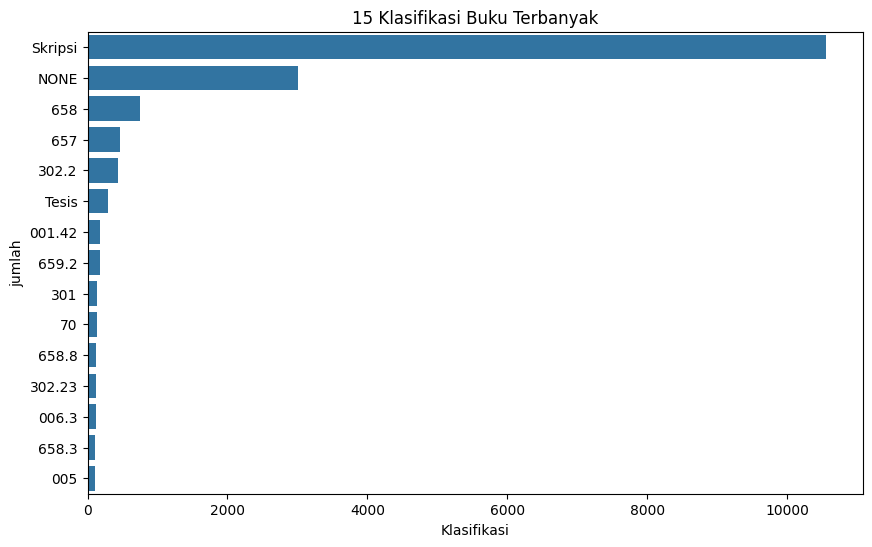

In [226]:
plt.figure(figsize=(10, 6))
sns.countplot(data=upn_books, y='classification_norm', order=upn_books['classification_norm'].value_counts().head(15).index)
plt.title('15 Klasifikasi Buku Terbanyak')
plt.ylabel('jumlah')
plt.xlabel('Klasifikasi')

In [227]:
upn_books[upn_books['classification_norm'] == 'NONE'][['title','call_number']]

,title,call_number
163,Edible Coatings And Films To Improve Food Quality,664.068 5 EDI e
166,Starch Hydrolysis Products: Worlwide Technolog...,664.2 STA s
300,"PENGARUH INKLUSI KEUANGAN, GAYA HIDUP, DAN PER...",NaN
398,Vogel buku teks analisis anorganik kualitatif ...,546 VOG v
419,Ice cream,641.862 MAR i
...,...,...
51765,Combustion theory: the fundamental theory of c...,541.361
51766,Chemical background for the biological sciences,540
55076,Perilaku organisasi buku satu,302.35
55077,Indonesian highway capacity manual (HCM),388.31


call number ya klasifikasinya

In [228]:
upn_books['call_number_clean'] = upn_books['call_number'].str.split().str[0]
show(upn_books[upn_books['classification_norm'] == 'NONE'][['title','call_number_clean', 'call_number']])

Loading ITables v2.7.0 from the internet... (need help?)


In [229]:
upn_books.loc[upn_books['classification_norm'].isna(), 'classification_norm'] = upn_books['call_number_clean']
upn_books['classification_norm'].value_counts()

classification_norm
Skripsi    10547
NONE        3008
658          941
657          680
302.2        529
           ...  
643.58         1
005.422        1
004.338        1
003.5          1
005.114        1
Name: count, Length: 7920, dtype: int64

In [230]:
show(upn_books['call_number_clean'].value_counts())

Loading ITables v2.7.0 from the internet... (need help?)


In [231]:
upn_books.loc[upn_books['classification_norm'] == 'NONE', 'classification_norm'] = upn_books['call_number_clean']
upn_books['classification_norm'].value_counts()

classification_norm
Skripsi    10547
658          960
657          689
302.2        535
658.8        387
           ...  
643.58         1
005.422        1
004.338        1
003.5          1
005.114        1
Name: count, Length: 8197, dtype: int64

In [232]:
upn_books['classification_norm'].isna().sum()

np.int64(8713)

In [233]:
upn_books['call_number'].isna().sum()

np.int64(8715)

In [234]:
upn_books['call_number_clean'].isna().sum()

np.int64(8715)

In [235]:
show(upn_books[upn_books['call_number_clean'].isna()])

Loading ITables v2.7.0 from the internet... (need help?)


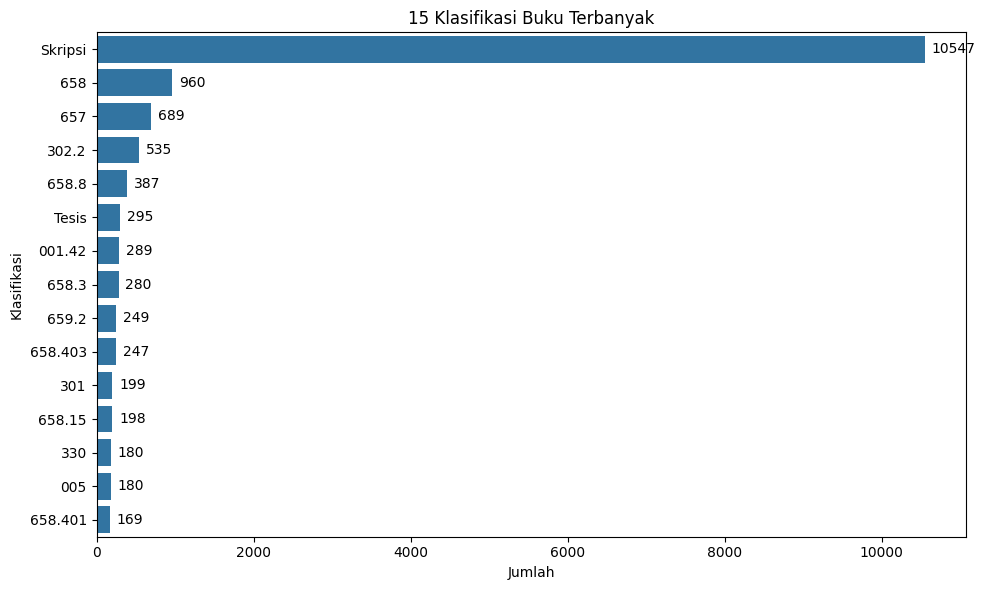

In [236]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=upn_books,
    y='classification_norm',
    order=upn_books['classification_norm'].value_counts().head(15).index
)
plt.title('15 Klasifikasi Buku Terbanyak')
plt.ylabel('Klasifikasi')
plt.xlabel('Jumlah')
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points'
    )
plt.tight_layout()
plt.show()

In [237]:
show(upn_books['classification_norm'].value_counts())

Loading ITables v2.7.0 from the internet... (need help?)


In [238]:
upn_books[upn_books['classification_norm'].str.contains('-', case=False, na=False)][['title', 'classification', 'call_number']]

,title,classification,call_number
31366,INTRODUCTION TO BUSINESS PENGANTAR BISNIS,NONE,-068 THO i
31729,INFORMATION TECHNOLOGY. PENGENDALIAN PRAKTIS D...,NONE,020-006
43133,Pembangunan Ekonomi Jilid 1,NaN,338-9STE p
44138,Experimental Design and Process Optimization,NaN,620-109 237 8 ROD e
44880,"Kepres Tentang APBN, APBD dan DIPA Petunjuk Pe...",NaN,343-03
48235,Lahan Rawa : Sifat dan Pengelolaan Tanah Berma...,NaN,631-42
49176,Sekelumit pengalaman semasa revolusi 1945 - 1950,NaN,959-803


In [239]:
def label_classification(call_num):
    call_map = {
        '0': 'Karya Umum',
        '1': 'Filsafat',
        '2': 'Agama',
        '3': 'Ilmu Sosial',
        '4': 'Bahasa',
        '5': 'Ilmu Pengetahuan Murni',
        '6': 'Ilmu Pengetahuan Terapan/Teknologi',
        '7': 'Seni, Olahraga',
        '8': 'Kesusastraan Sejarah, Geografi',
    }
    
    special_cases = ['SKRIPSI', 'TESIS', 'JURNAL', 'MAJALAH']

    if pd.isna(call_num):
        return 'Lainnya'
    
    main_num = call_num.split('.')[0]  # Ambil bagian sebelum titik jika ada
    
    call_str = str(call_num).upper().strip()

    for case in special_cases:
        if case in call_str:
            return case.capitalize()  

    if main_num[0].isdigit():
        first_digit = call_str[0]
        return call_map.get(first_digit, 'Lainnya')
    
    return 'Lainnya'

In [240]:
upn_books['call_label'] = upn_books['classification_norm'].apply(label_classification)

In [241]:
label_counts = upn_books['call_label'].value_counts()
label_counts

call_label
Ilmu Sosial                           12721
Skripsi                               10547
Ilmu Pengetahuan Terapan/Teknologi    10398
Lainnya                               10194
Karya Umum                             3798
Ilmu Pengetahuan Murni                 2357
Seni, Olahraga                         1834
Kesusastraan Sejarah, Geografi         1010
Filsafat                                935
Agama                                   628
Bahasa                                  421
Tesis                                   295
Majalah                                  15
Jurnal                                    7
Name: count, dtype: int64

In [242]:
show(upn_books[upn_books['call_label'] == 'Lainnya'][['title', 'classification', 'classification_norm', 'call_number', 'call_label']])

Loading ITables v2.7.0 from the internet... (need help?)


In [243]:
show(upn_books[['classification_norm', 'call_number', 'call_label']])

Loading ITables v2.7.0 from the internet... (need help?)


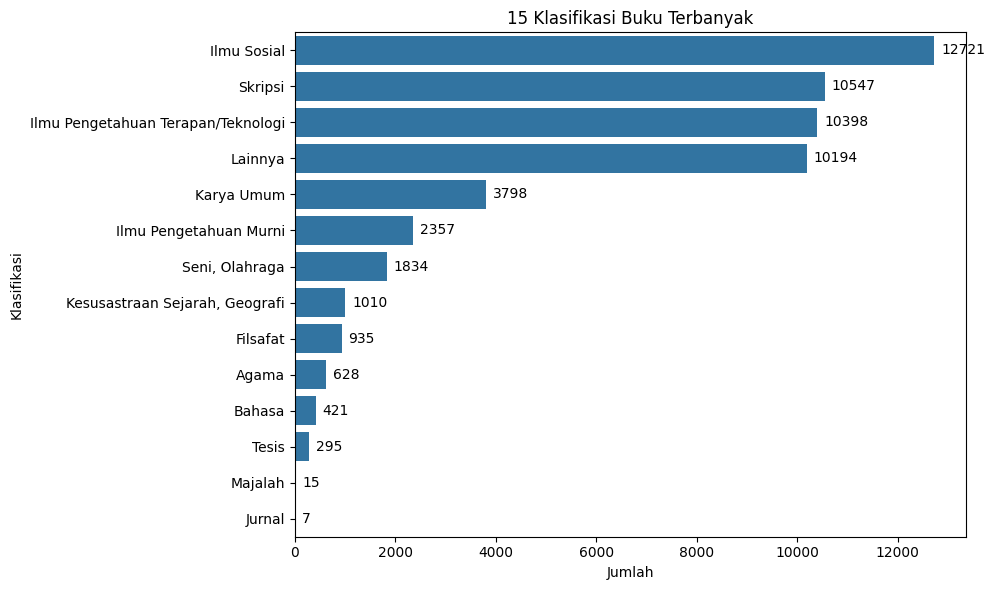

In [244]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=upn_books,
    y='call_label',
    order=upn_books['call_label'].value_counts().head(15).index
)
plt.title('15 Klasifikasi Buku Terbanyak')
plt.ylabel('Klasifikasi')
plt.xlabel('Jumlah')
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points'
    )
plt.tight_layout()
plt.show()

In [245]:
upn_books[upn_books['call_label'] == 'Lainnya'][['title', 'classification', 'classification_norm', 'call_number', 'call_label']]

,title,classification,classification_norm,call_number,call_label
49,MATEMATIKA EKONOMI DAN BISNIS,9161511,9161511,9161511,Lainnya
300,"PENGARUH INKLUSI KEUANGAN, GAYA HIDUP, DAN PER...",NONE,NaN,NaN,Lainnya
445,Kamus Sejarah Lengkap,959.03,959.03,959.03 PAM k,Lainnya
854,Pokok-Pokok Pengetahuan Hukum Dagang Indonesia,HUKUMDAGANG,HUKUMDAGANG,- HUKUM DAGANG,Lainnya
1639,"Bisnis, jilid 1",NONE,920,920,Lainnya
...,...,...,...,...,...
54810,Hukum bisnis : suatu pengantar,NaN,952,952,Lainnya
54883,Controllership the work of the managerial acco...,NaN,92,92 (HABIBIE),Lainnya
54919,Business economic planning : Theory practice a...,NaN,959.8,959.8,Lainnya
55018,Guidelines for project evaluation,NaN,920,920,Lainnya


### isbn 

In [246]:
import re

def normalize_isbn(isbn_str):
    if pd.notna(isbn_str):
        # isbns = isbn_str.split('-')
        # normalized_isbns = [isbn.strip(' ') for isbn in isbns]
        normalized_isbns = re.sub(r'[^a-zA-Z0-9]', '', isbn_str)
        return ''.join(normalized_isbns)

In [247]:
upn_books['isbn_issn_norm'] = upn_books['isbn_issn'].apply(normalize_isbn)

In [248]:
show(upn_books[['isbn_issn', 'isbn_issn_norm']])

Loading ITables v2.7.0 from the internet... (need help?)


In [249]:
upn_books[upn_books['isbn_issn_norm'].str.contains(',', case=False, na=False)]

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,image,sor,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm


In [250]:
upn_books['isbn_issn_norm'].notna().sum()

np.int64(34946)

In [251]:
upn_books['isbn_issn_norm'].nunique()

26611

In [252]:
upn_books['isbn_issn_norm'].value_counts().head(10)

isbn_issn_norm
9789797694173    24
9795149938       22
9795141457       22
9799812305       21
9798433025       19
14117371         18
20853998         18
9797691128       17
9794216887       17
9798433640       17
Name: count, dtype: int64

In [253]:
upn_books[upn_books['isbn_issn_norm'] == '9795141457']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,image,sor,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm
34093,Psikoogi Komunikasi,Text,NaN,979-514-145-7,PT Remaja Rosda Karya,2007,NaN,NaN,658.4 ja p,Indonesia,...,NaN,NaN,"<Drs.Rakhmat Jaauddin,M.Sc>",<PSIKOOGI KOMUNIKASI>,<0490016801>,NaN,658.4,658.4,Ilmu Pengetahuan Terapan/Teknologi,9795141457
34129,Psikoogi KomunikasiPsikoogi,Text,NaN,979-514-145-7,Remaja Rosda Karya,2000,xiii.;332ha.;24cm,NaN,150 rak p,Indonesia,...,NaN,NaN,"<Rahmat,Jaaudin>",<PSIKOOGI>,<0490020401>,NaN,150,150,Filsafat,9795141457
34398,PSIKOOGI KOMUNIKASI,Text,NaN,979-514-145-7,ROSDAKARYA,2007,xiii.;303ha.;20cm,NaN,153.5 JA P,Indonesia,...,NaN,NaN,<RAKHMAT JAAUDIN>,<PSIKOOGI>,<0490047401>,NaN,153.5,153.5,Filsafat,9795141457
34661,Psikoogi Komunikasi,Text,NaN,979-514-145-7,Remaja Rosdakarya,2007,xiii.;332ha.;24cm,NaN,153.6 rak p,Indonesia,...,NaN,NaN,"<Rakhmat,Jaaudin>",<PSIKOOGI>,<0490074001>,NaN,153.6,153.6,Filsafat,9795141457
35022,psikoogis komunikasi,Text,NaN,979-514-145-7,Remaja Rosdakarya,1994,xiii.;332ha.;20cm,NaN,153.6 rak p,Indonesia,...,NaN,NaN,<Drs. Jaauddin Rakhmat>,<PSIKOOGIS>,<0490110301>,NaN,153.6,153.6,Filsafat,9795141457
35097,psikoogis komunikasi,Text,NaN,979-514-145-7,Remaja Rosdakarya,2005,xiii.;332ha.;21cm,NaN,153.6 ja p,Indonesia,...,NaN,NaN,<Drs. Jaauddin R>,<PSIKOOGIS>,<0490118001>,NaN,153.6,153.6,Filsafat,9795141457
36184,Psikoogi Komunikasi,Text,NaN,979-514-145-7,Remja Rosdakarya,2005,xiii;332ha;21cm,NaN,153.6 ja p,Indonesia,...,NaN,NaN,"<DRS. Rakhmat, Jaauddin>",<PSIKOOGI>,<0490227101>,NaN,153.6,153.6,Filsafat,9795141457
36822,PENGANTAR KOMUNIKASI MASSA,Text,NaN,979-514-145-7,ROSDAKARYA,2008,"xiii,;332hm,25cm",NaN,15306 ja p,Indonesia,...,NaN,NaN,<RAKHMAT JAAUDIN>,<PSIKOOGI KOMUNIKASI>,<0490291101>,NaN,15306,15306,Filsafat,9795141457
36845,pengantar MSDM,Text,NaN,979-514-145-7,ROSDAKARYA,2011,xiii.;299ha.;23cm,NaN,153 rak p,Indonesia,...,NaN,NaN,"<Rahmat ,jaaudin>",<PSIKOOGI KOMUNIKASI>,<0490293401>,NaN,153,153,Filsafat,9795141457
37133,1510 ikom,Text,NaN,979-514-145-7,Rosda,2012,NaN,NaN,1583.6 rak p,Indonesia,...,NaN,NaN,<jaauddin rakhmat>,<PSIKOOGI KOMUNIKASI>,<0490322301>,NaN,1583.6,1583.6,Filsafat,9795141457


In [254]:
upn_books[upn_books['title'] == 'Psikologi komunikasi']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,image,sor,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm
42866,Psikologi komunikasi,Text,NaN,978-979-514-145-7,PT Remaja Rosda Karya,410,"xiii, 318 p.; 23 cm.",NaN,153.6 RAK p,Indonesia,...,NaN,NaN,"<Rakhmat, Jalaluddin>",<COMMUNICATION IN PSYCHOLOGY>,NaN,NaN,153.6,153.6,Filsafat,9789795141457
49090,Psikologi komunikasi,Text,text,979-514-145-7,Remaja Rosdakarya,1993,"xiii, 332p.; bibl.; 23 cm.",NaN,153.6,Indonesia,...,NaN,NaN,"<Rakhmat, Jalaluddin>",<Communication in psichology>,<90590801><91179601><90590802><91179602><90590...,NaN,153.6,153.6,Filsafat,9795141457


In [255]:
upn_books[upn_books['isbn_issn_norm'] == '9795149938']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,image,sor,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm
32532,Ilmu komunikasi suatu pengantar,Text,NaN,979-514-993-8,Remaja Rosda Karya,2004,"xiv, 410 p.; 25 cm.",NaN,302.2 MUL i,Indonesia,...,NaN,NaN,"<Mulyana, Deddy>",<Communication>,<90008101><90008102><90008103><90008104><90008...,NaN,302.2,302.2,Ilmu Sosial,9795149938
34196,Imu Komunikasi,Text,NaN,979-514-993-8,Rosda,2007,xvii.;466ha.;26cm,NaN,302.2 ded i,Indonesia,...,NaN,NaN,"<Muyana,Dedy>",<IMU>,<0490027201>,NaN,302.2,302.2,Ilmu Sosial,9795149938
34237,IMU KOMUNIKASI SUATU PENGANTAR,Text,NaN,979-514-993-8,PT Remaja Rosda Karya,2008,NaN,NaN,302.2 ded i,Indonesia,...,NaN,NaN,"<Prof.Muyana.E,M.A.,Ph.D.>",<IMU>,<0490031301>,NaN,302.2,302.2,Ilmu Sosial,9795149938
34389,SUATU PENGANTAR IMU KOMUNIKASI,Text,NaN,979-514-993-8,Remaja Rosdakarya,2007,xvii;466ha.;25cm,NaN,302.2 DED I,Indonesia,...,NaN,NaN,"<MUYANA, DEDDY>",<SUATU>,<0490046501>,NaN,302.2,302.2,Ilmu Sosial,9795149938
34907,imu komunikasi,Text,NaN,979-514-993-8,Remaja Rosdakarya,2001,xiv.;410ha.;21cm,NaN,003.3,Indonesia,...,NaN,NaN,<Dedy muyana>,<IMU>,<0490098801>,NaN,003.3,003.3,Karya Umum,9795149938
34995,Imu Komunikasi,Text,NaN,979-514-993-8,ROSDAKARYA,2000,xiv.;409ha.;23cm,NaN,003.3,Indonesia,...,NaN,NaN,"<Muyana,Dedy>",<IMU KOMUNIKASI>,<0490107601>,NaN,003.3,003.3,Karya Umum,9795149938
35005,Imu Komunikasi,Text,NaN,979-514-993-8,ROSDAKARYA,2007,xvii.;466ha.;23cm,NaN,302.2 mu i,Indonesia,...,NaN,NaN,"<Muyana,Dedy>",<IMU KOMUNIKASI>,<0490108601>,NaN,302.2,302.2,Ilmu Sosial,9795149938
35079,Suatu pengantar imu komunikasi,Text,NaN,979-514-993-8,Remaja Rosdakarya,2007,xvii.;466ha.;25cm,NaN,302.2 ded i,Indonesia,...,NaN,NaN,<Prof. Deddy Muyana>,<SUATU>,<0490116201>,NaN,302.2,302.2,Ilmu Sosial,9795149938
35262,Imu Komunikasi,Text,NaN,979-514-993-8,Rosda,2007,xvii.;466ha.;23cm,NaN,302.2 ded i,Indonesia,...,NaN,NaN,"<Muyana,Dedy>",<IMU KOMUNIKASI>,<0490134501>,NaN,302.2,302.2,Ilmu Sosial,9795149938
35557,arus baik kekuasaan pusat ke daerah,Text,NaN,979-514-993-8,Sinar Harapan,2002,NaN,NaN,352.000.473 sar k,Indonesia,...,NaN,NaN,<S.H. Sarundajang>,<ARUS>,<0490164001>,NaN,352.000.473,352.000.473,Ilmu Sosial,9795149938


In [256]:
upn_books[upn_books['isbn_issn_norm'].isna()]['classification'].value_counts()

classification
SKRIPSI                8054
TUGASAKHIR             1219
NONE                    585
TESIS                   261
658                     108
                       ... 
711.78                    1
SkripsiADNI009/2023       1
TesisMIL001/2022          1
TESISIL                   1
SADBIS                    1
Name: count, Length: 1313, dtype: int64

rata-rata ngga ada isbn = skripsi sih

### publish year

In [257]:
upn_books['publish_year'].value_counts()

publish_year
2024    5693
2023    4211
2025    3726
2019    2244
2006    1588
        ... 
Ban        1
Sosi       1
(S.a       1
[s.a       1
19..       1
Name: count, Length: 279, dtype: int64

In [258]:
upn_books['publish_year'].value_counts().head(20)

publish_year
2024    5693
2023    4211
2025    3726
2019    2244
2006    1588
2007    1545
2008    1411
2022    1406
2009    1382
2020    1377
2021    1363
2018    1233
2017    1228
2016    1216
2015    1188
2005    1187
2010    1159
2014    1150
2004    1125
2011    1066
Name: count, dtype: int64

In [259]:
upn_books['publish_year'].value_counts().sort_index()

publish_year
(S.a              1
(s.a             17
-                 2
1                 1
1001              1
                 ..
OKTOBER 2013      1
SALEMBA EMPAT     1
Sosi              1
[s.a              1
s.a.              2
Name: count, Length: 279, dtype: int64

In [260]:
upn_books["clean_year"] = pd.to_numeric(upn_books['publish_year'], errors='coerce').astype('Int64')
upn_books['clean_year'].value_counts().sort_index()

clean_year
1        1
20       1
186      1
201      8
202      3
        ..
7007     1
20007    2
20011    2
20016    1
22025    1
Name: count, Length: 261, dtype: Int64

In [261]:
upn_books['publish_year'].value_counts().sort_index(ascending=True).head(10)

publish_year
(S.a     1
(s.a    17
-        2
1        1
1001     1
1432     1
1690     2
1712     2
1718     2
1736     2
Name: count, dtype: int64

In [262]:
upn_books['publish_year'].value_counts().sort_index(ascending=True).tail(35)

publish_year
2017257 hlm             1
2018                 1233
2019                 2244
202                     3
2020                 1377
2021                 1363
2022                 1406
2023                 4211
2024                 5693
2025                 3726
2026                    1
207                     3
2101                    1
22025                   1
2206                    1
2500                    1
2913                    1
2917                    2
2918                    1
410                   186
7007                    1
974                     1
975                     1
976                     2
978-979-27-3386-0       1
979-421-509-0           1
Ban                     1
DESEMBER 2015           1
INDAH SURABAYA          1
Jatim";2004"            1
OKTOBER 2013            1
SALEMBA EMPAT           1
Sosi                    1
[s.a                    1
s.a.                    2
Name: count, dtype: int64

butuh di benerin apalah sa tu

In [263]:
upn_books[upn_books['publish_year'] == '410']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,sor,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm,clean_year
2600,Pengantar Akuntansi : konsep dan teknik penyus...,Text,NaN,978-602-241-106-2,Erlangga,410,"ix, 297 p.; 24 cm.",NaN,657 RUD p,Indonesia,...,NaN,<Rudianto>,<Accounting>,<91190801><91190902><91190903>,NaN,657,657,Ilmu Pengetahuan Terapan/Teknologi,9786022411062,410
24707,Pengantar Ekonomi Pertanian,Text,NaN,978-602-9056-39-6,ITB,410,"10a, 214 p.; 21 cm",NaN,338.1 YOG p,Indonesia,...,NaN,<Yogi>,<Agricultural economics>,<91246802>,NaN,338.1,338.1,Ilmu Sosial,9786029056396,410
24859,Perencanaan Bangunan Pantai,Text,NaN,978-979-8541-58-2,Beta Offset,410,"x, 327 p; 20 cm",NaN,627.58 BAM p,Indonesia,...,NaN,<Bambang Triatmodjo>,<COASTAL ENGINERING>,<91189201><91189202><91189203><FTS00086>,NaN,627.58,627.58,Ilmu Pengetahuan Terapan/Teknologi,9789798541582,410
27494,Ekonomi manajerial,Text,NaN,978-979-769-488-5,Rajagrafindo,410,"xxxiv, 544 p.; 26 cm.",NaN,658.403 NOO e,Indonesia,...,NaN,"<Noor, Henry Faizal>",<Managerial economics>,<91180702><91180701>,NaN,658.403,658.403,Ilmu Pengetahuan Terapan/Teknologi,9789797694885,410
30089,"Pendidikan Kewarganegaraan:Pancasila,Demokrasi...",Text,NaN,979-3465-03-4,NaN,410,250;23,NaN,321.8UBA p,Indonesia,...,NaN,<Ubaedillah>,<INDONESIA-NATIONAL SECURITY>,<91213801><91213802><91213803>,NaN,321.8UBA,321.8UBA,Ilmu Sosial,9793465034,410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44027,Mesozoic geology and paleontology of misool ar...,Text,NaN,978-602-9105-23-0,geological agency,410,"xvi, 230 p.; 23 cm.",NaN,551 FAU m,NaN,...,NaN,<Fauzie Hasibuan>,<Geology>,<91274301>,NaN,551,551,Ilmu Pengetahuan Murni,9786029105230,410
44108,Insect pests in tropical forestry,Text,NaN,978-84593-635-8,NaN,410,"ix, 365 p.; ill.; ind.; 23 cm",NaN,595.717 34 WYL i,NaN,...,NaN,"<Wylie, F. Ross>",<FOREST INSECTS-TROPICS>,<91303001><91303002>,NaN,595.717,595.717,Ilmu Pengetahuan Murni,978845936358,410
44288,"Natural ventilation of buildings : theory, mea...",Text,NaN,9780470660355,John Wiley & Sons,410,"xvi, 428 p.; ill.; ind.; 23 cm.",NaN,697.92 ETH n,NaN,...,NaN,"<Etheridge, David>",<NATURAL VENTILATION>,<91328601>,NaN,697.92,697.92,Ilmu Pengetahuan Terapan/Teknologi,9780470660355,410
44323,Crime and Punishment,Text,NaN,978-0-19-873809-1,Oxford University Press,410,"XV, 219p.; ind.; 24cm",NaN,364.941 GRO c,NaN,...,NaN,"<Gross, Hyman>",<PUNISHMENT-MORAL AND ETHNICAL ASPECTS>,<91332701><91332702>,NaN,364.941,364.941,Ilmu Sosial,9780198738091,410


In [264]:
upn_books[upn_books['clean_year'] == 201].head()

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,sor,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm,clean_year
40396,Konsep dasar keterampilan menulis,Text,NaN,978-602-6643-54-4,Parama Ilmu,201,x : 159 hal.; 20 cm,NaN,807 NGA k,Indonesia,...,NaN,<Ngalimun>,<SASTRA>,<91673801><91673802>,NaN,807,807,"Kesusastraan Sejarah, Geografi",9786026643544,201
41982,Kanker : Pengobatan & Penyembuhannya,Text,NaN,978-602-1351-05-5,Parama Ilmu,201,232 hlm.; 18 cm,NaN,616.9 WAW k,Indonesia,...,NaN,<Wawan Supriyanto>,<PATOLOGI>,<91673001><91673002>,NaN,616.9,616.9,Ilmu Pengetahuan Terapan/Teknologi,9786021351055,201
42001,Prinsip Dasar Tenaga Penggerak Dengan Plasma ION,Text,NaN,9786022625629,Graha Ilmu,201,ix : 117 hal.; 26 cm,NaN,621.382 SAL p,Indonesia,...,NaN,<Saludin Muis>,<PENGGERAK PLASMA ION>,<91675101><91675102>,NaN,621.382,621.382,Ilmu Pengetahuan Terapan/Teknologi,9786022625629,201
42009,Langkah menyusun siklus akuntansi (accounting ...,Text,NaN,9786026469908,In Media,201,viii :178 Hal. ; 24 cm.,NaN,657 ANI l,Indonesia,...,NaN,<Ani Rahmaniar>,<Accounting>,<91675901><91675902>,NaN,657,657,Ilmu Pengetahuan Terapan/Teknologi,9786026469908,201
42013,Official statistics sosial-kependudukan dasar,Text,NaN,978-602-0946-70-2,In Media,201,x : 193 hlm.; Ilus.; 24 cm,NaN,310 PUG o,Indonesia,...,NaN,<Puguh Bodro Irawan>,<STATISTIK>,<91676301><91676302>,NaN,310,310,Ilmu Sosial,9786020946702,201


Prinsip Dasar Tenaga Penggerak Dengan Plasma ION	 => 2016
Official statistics sosial-kependudukan dasar => 2016

diasumsikan 201 = 2016

### call number

In [265]:
upn_books['call_number'].value_counts()

call_number
658           227
657           192
001.42        184
658.8         180
301           131
             ... 
005.422 82      1
004.338 1       1
005.84          1
003.5           1
005.114         1
Name: count, Length: 28160, dtype: int64

In [266]:
call_number_index = {
    '001': '??',
    '301': '301',
    '658.8': '658.8',
    '658': '658',
    '658.8': '658.8'
}

### topics form

In [267]:
upn_books['topics'] = upn_books['topics'].fillna('')

In [268]:
def normalize_topics(topics_input):
    topics_input_str = str(topics_input)
    topics = topics_input_str.strip('<>')
    topics = topics.split('><')
    lists = []
    for group in topics:
        for name in group.split(';'):
            lists.append(name.strip())
    return ', '.join(lists)

In [269]:
upn_books['topics'] = upn_books['topics'].apply(normalize_topics)
upn_books.sample(5)

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,sor,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm,clean_year
34184,INDONESIA DI ERA DUNIA MAYA,Text,NaN,979-692-032-8,PT.REMAJA ROSDAKARYA,2001,NaN,NaN,003.5 MUI I,Indonesia,...,NaN,<A.MUI>,Indonesia,<0490026001>,NaN,3.5,003.5,Ilmu Sosial,9796920328,2001
33767,Fisika Tubuh Manusia E-2,Text,NaN,NaN,NaN,NaN,NaN,NaN,610.153,Indonesia,...,NaN,<CAMERON>,Medical Physics,<09900126>,NaN,610.153,610.153,Ilmu Pengetahuan Terapan/Teknologi,NaN,<NA>
52440,Ecology and the quality of our environment,Text,text,0-442-27921-3,D. Van Nortrand Company,1976,"xxi, 426p.; ill.; ind.; 23 cm.",NaN,574.5,NaN,...,NaN,"<Southwick, Charles H.>",Ecology - Social Aspects,<90249601><90249602>,NaN,574.5,574.5,Ilmu Pengetahuan Murni,0442279213,1976
15896,The citizen's stake: exploring the future of u...,Electronic Resource,NaN,9781847421463,IG Library,2006,225,NaN,361.65,English,...,NaN,"<Paxton, Will;White, Stuart;Maxwell, Dominic>",,<610801>,NaN,361.65,361.65,Ilmu Sosial,9781847421463,2006
2862,"Analisis Pengaruh Investasi, Tenaga Kerja dan ...",Text,NaN,NaN,Fakultas Ekonomi dan Bisnis UPN Veteran Jawa...,2025,NaN,NaN,SKRIPSI EP 055/2025,Indonesia,...,NaN,"<Pramesti, Syaharani Cahyani>",,<825110055>,NaN,Skripsi,SKRIPSI,Skripsi,NaN,2025


In [270]:
upn_books['topics'] = (upn_books['topics'].str.lower())

In [271]:
upn_books['topics'].value_counts().head(20)

topics
                       30983
ekonomi                 1382
accounting               332
manajemen                261
management               251
marketing                197
economics                184
hukum                    161
chemistry                139
business                 125
komunikasi               122
statistics               122
pengantar                109
auditing                 101
ekonomi pembangunan       96
communication             94
macroeconomics            91
leadership                88
cost accounting           87
metode                    84
Name: count, dtype: int64

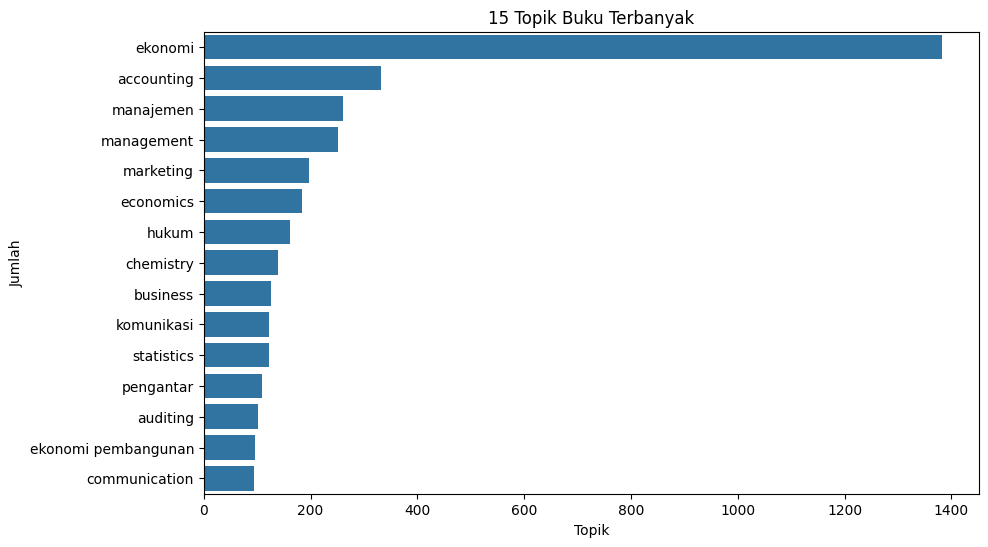

In [272]:
topic_filter_df = upn_books[upn_books["topics"] != ""]
plt.figure(figsize=(10, 6))
sns.countplot(
    data=topic_filter_df,
    y="topics",
    order=topic_filter_df["topics"].value_counts().head(15).index
)
plt.title("15 Topik Buku Terbanyak")
plt.ylabel("Jumlah")
plt.xlabel("Topik")
plt.show()


### Language

In [273]:
upn_books['language_name'].value_counts()

language_name
Indonesia    28622
English      19909
Surabaya         2
Name: count, dtype: int64

In [274]:
upn_books[upn_books['language_name'] == 'Surabaya']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,sor,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm,clean_year
2019,ANALISIS WACANA KRITIS PADA PODCAST “GURU GEMB...,NaN,NaN,"fakultas ilmu sosial, budaya dan politik",2025,NaN,NaN,SKRIPSI IKOM 114/2025,Indonesia,Surabaya,...,<Rahmat Noval Herlambang>,NaN,"825430114, 825430115",NaN,NaN,Indonesia,Indonesia,Lainnya,fakultasilmusosialbudayadanpolitik,<NA>
24369,EKSTRAKSI SENYAWA FLAVONOID DARI KULIT ARI BUA...,NaN,NaN,Fakultas Teknik UPN Veteran Jawa Timur,2024,NaN,NaN,SKRIPSI TK 238/2024,Indonesia,Surabaya,...,<Nilam Sekar Ningsih>,NaN,824310238,NaN,NaN,Indonesia,Indonesia,Lainnya,FakultasTeknikUPNVeteranJawaTimur,<NA>


how can?

In [275]:
from lingua import Language, LanguageDetectorBuilder

languages = [Language.ENGLISH, Language.DUTCH, Language.INDONESIAN]
detector = LanguageDetectorBuilder.from_languages(*languages).build()

def detect_language(text):
    if pd.isna(text) or str(text).strip() == "": 
        return "Unknown"
    
    result = detector.detect_language_of(str(text))
    
    return result.name.title() if result else "Unknown"


In [276]:
upn_books['language_detect'] = upn_books['title'].apply(detect_language)
upn_books['language_detect'].value_counts()

language_detect
Indonesian    27387
English       26494
Dutch          1270
Unknown           9
Name: count, dtype: int64

In [277]:
upn_books[upn_books['language_detect'] == 'Dutch']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm,clean_year,language_detect
3691,"Deleuze and Marx : Deleuze Studies, volume 3: ...",Electronic Resource,NaN,9781474469555,Edinburgh University Press (EUP),2019,149,NaN,194,English,...,"<Jain, Dhruv>","psychology, philosophy, religion, by period, b...",<618182>,NaN,194,194,Filsafat,9781474469555,2019,Dutch
5663,"Sagaing district (Burma gazetteer), volume B",Electronic Resource,NaN,NaN,Heritage Books of Asia,1913,51,NaN,NaN,English,...,NaN,,<615969>,NaN,NaN,NaN,Lainnya,NaN,1913,Dutch
5665,"Upper chindwin district (Burma gazetteer), vol...",Electronic Resource,NaN,NaN,Heritage Books of Asia,1913,64,NaN,NaN,English,...,NaN,,<615971>,NaN,NaN,NaN,Lainnya,NaN,1913,Dutch
5738,"Burma gazetteer: upper chindwin district, Volu...",Electronic Resource,NaN,NaN,Heritage Books of Asia,1913,142,NaN,NaN,English,...,"<Brown, G. E. R. Grant>",,<616045>,NaN,NaN,NaN,Lainnya,NaN,1913,Dutch
5871,The talaings,Electronic Resource,NaN,NaN,Heritage Books of Asia,1917,193,NaN,NaN,English,...,"<Halliday, R.>",,<616187>,NaN,NaN,NaN,Lainnya,NaN,1917,Dutch
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53632,Apel (malus sylvestris mill),Text,NaN,NaN,Yasaguna,1986,131p.; bibl.; ill.; 21cm.,NaN,895.1,Indonesia,...,"<Kusumo, Surachmat>",apple - harvesting,<90143901>,NaN,895.1,895.1,"Kesusastraan Sejarah, Geografi",NaN,1986,Dutch
54070,Circuirs,Text,NaN,0-07-065591-X,Mc Graw Hill,1977,"ix, 820 p.; ill.; ind.; 21 cm.",NaN,621.3,NaN,...,"<Tuttle, David F.>",electric circuits,<90063001>,NaN,621.3,621.3,Ilmu Pengetahuan Terapan/Teknologi,007065591X,1977,Dutch
54453,Aileen reid,Text,NaN,1-85841-137-8,"Bison Books, ltd",1995,112p.; ill.; 35 cm.,NaN,658.403,NaN,...,"<Pei, I.M.>","pei, i.m. 1917",<90121201>,NaN,658.403,658.403,Ilmu Pengetahuan Terapan/Teknologi,1858411378,1995,Dutch
55059,College algebra,Text,NaN,NaN,John Wiley & Sons,1961,"xvi, 440p.; ill.; ind.; 23 cm.",NaN,657.024,NaN,...,"<Leonhardy, Adele>",algebra,<90208801>,NaN,657.024,657.024,Ilmu Pengetahuan Terapan/Teknologi,NaN,1961,Dutch


In [278]:
upn_books[upn_books['language_detect'] == 'Unknown']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm,clean_year,language_detect
11876,360,Electronic Resource,NaN,9789355513397,BPB Online,2023,240,NaN,005.8,English,...,"<Moretti, Raphael Hungaro;Matsukawa, Emerson E.>",,<613972>,NaN,005.8,005.8,Karya Umum,9789355513397,2023,Unknown
12939,NaN,Electronic Resource,NaN,NaN,IG Library,1775,272,NaN,NaN,English,...,"<Bolts, Willem>",,<607832>,NaN,NaN,NaN,Lainnya,NaN,1775,Unknown
15268,360,Electronic Resource,NaN,9789355513397,IG Library,2023,240,NaN,005.8,English,...,"<Moretti, Raphael Hungaro;Matsukawa, Emerson E.>",,<610167>,NaN,005.8,005.8,Karya Umum,9789355513397,2023,Unknown
21702,NaN,Electronic Resource,NaN,NaN,IG Library,1775,272,NaN,NaN,NaN,...,"<Bolts, Willem>",,<606331>,NaN,NaN,NaN,Lainnya,NaN,1775,Unknown
33869,NaN,Text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,,NaN,NaN,NaN,NaN,Lainnya,NaN,<NA>,Unknown
38263,NaN,Text,NaN,NaN,Bintang Usaha Jaya,2003,"II, 358p; 20cm",NaN,297.1 HUS k,Indonesia,...,<Hussein Bahreisj>,sources of islam,NaN,NaN,297.1,297.1,Agama,NaN,2003,Unknown
38292,NaN,Text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indonesia,...,NaN,,NaN,NaN,NaN,NaN,Lainnya,NaN,<NA>,Unknown
38567,NaN,Text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indonesia,...,NaN,,NaN,NaN,NaN,NaN,Lainnya,NaN,<NA>,Unknown
42962,NaN,Text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indonesia,...,NaN,,NaN,NaN,NaN,NaN,Lainnya,NaN,<NA>,Unknown


In [279]:
show(upn_books[upn_books['language_detect'] != upn_books['language_name']][['title', 'language_name', 'language_detect']])

Loading ITables v2.7.0 from the internet... (need help?)


fill the language name from lang detect, but anyways

In [280]:
def normalize_lang(lang_detect, lang_name):
    if lang_detect == "Dutch":
        # If lang_name is English or missing, set it to Dutch
        if pd.isna(lang_name) or lang_name == "English":
            return "Dutch"
    if lang_name == "Surabaya" or lang_detect == "Indonesian" :
        return "Indonesia"
    if pd.isna(lang_name):
        return lang_detect
    if pd.isna(lang_detect):
        return np.nan
    return lang_name

In [281]:
upn_books['language_name'] = upn_books.apply(lambda row: normalize_lang(row["language_detect"], row["language_name"]), axis=1)

upn_books['language_name'].value_counts()


language_name
Indonesia    29299
English      24676
Dutch         1183
Unknown          2
Name: count, dtype: int64

In [282]:
upn_books['language_name'].unique()

<ArrowStringArray>
['Indonesia', 'English', 'Dutch', 'Unknown']
Length: 4, dtype: str

In [283]:
upn_books[upn_books['language_detect'] != upn_books['language_name']][['title', 'language_name', 'language_detect']]

,title,language_name,language_detect
0,Pengaruh Environmental Social and Governance (...,Indonesia,Indonesian
1,"Pemasaran jasa,manusia,teknologi,strategi pers...",Indonesia,Indonesian
2,"Pemasaran jasa,manusia,teknologi,strategi",Indonesia,Indonesian
3,PENGARUH DURASI PENGOPERASIAN MEMBRAN PVC-TiO2...,Indonesia,Indonesian
4,Desain Struktur Bangunan Pelimpah (Spillway) P...,Indonesia,Indonesian
...,...,...,...
55136,Letter of credit: tinjauan aspek hukum dan bisnis,Indonesia,Indonesian
55137,Era baru bisnis telekomunikasi,Indonesia,Indonesian
55138,"Human communication : prinsip-prinsip dasar, b...",Indonesia,Indonesian
55139,HTML 4.01 weekend crash course,Indonesia,English


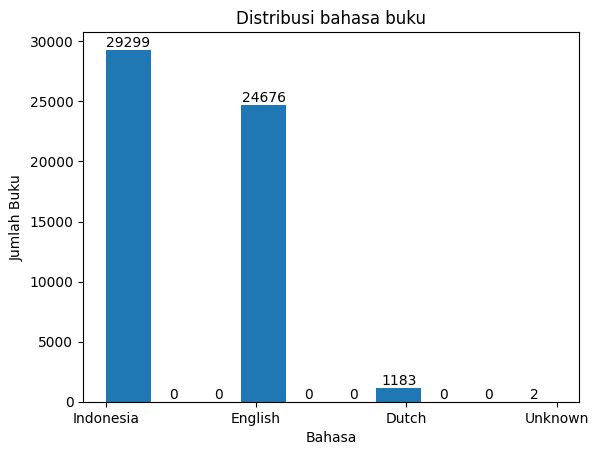

In [284]:
data = upn_books['language_name']
counts, bins, patches = plt.hist(data, bins=10)
for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width() / 2,
        count,
        int(count),
        ha='center',
        va='bottom'
    )
plt.title('Distribusi bahasa buku')
plt.xlabel('Bahasa')
plt.ylabel('Jumlah Buku')
plt.show()

In [285]:
import plotly.express as px

# Calculate the order (optional, but keeps your descending sort)
counts = upn_books['language_name'].value_counts().reset_index()

fig = px.histogram(
    upn_books, 
    y='language_name', 
    orientation='h',
    category_orders={'language_name': counts['language_name'].tolist()},
    title='Distribusi bahasa buku berdasarkan deteksi bahasa dari judul',
    labels={'language_detect': 'Bahasa', 'count': 'Jumlah Buku'}
)

# Optional: Clean up the layout
fig.update_layout(
    yaxis_title="Bahasa",
    xaxis_title="Jumlah Buku",
    width=600, 
    height=400
)

fig.show()


### etc

In [286]:
upn_books[upn_books['gmd_name'] == 'Text']['classification'].value_counts()

classification
SKRIPSI                8054
NONE                   2377
TUGASAKHIR             1219
658                     719
657                     468
                       ... 
711.78                    1
SkripsiADNI009/2023       1
TesisMIL001/2022          1
TESISIL                   1
SADBIS                    1
Name: count, Length: 2487, dtype: int64

ya allah, i am cooked....

In [287]:
upn_books.sort_values(by='item_code').head(20)

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,authors,topics,item_code,Unnamed: 18,classification_norm,call_number_clean,call_label,isbn_issn_norm,clean_year,language_detect
3026,PABRIK ETIL ASETAT DARI ETIL ALKOHOL DAN ASAM ...,Text,NaN,NaN,Fakultas Teknik dan Sains UPN Veteran Jawa imur,2025,NaN,NaN,TUGAS AKHIR TK 032/2025,Indonesia,...,"<Abdullah, Affan Zein>",,<+725310032>,NaN,Skripsi,TUGAS,Skripsi,NaN,2025,Indonesian
24922,PETROLEUM REFINERY ENGINERING,Text,NaN,0-07-Y85536-6,McGraw-Hill International,1985,"25CM, 939 HAL",NaN,660.03 NE L,English,...,<W.L. NELSON>,,<0.660.03>,NaN,660.03,660.03,Ilmu Pengetahuan Terapan/Teknologi,007Y855366,1985,English
30753,"TEORI,SOAL DAN PEMBAHASAN STATISTIKA",Text,NaN,978-602-8963-37-4,"REDAKSI @ PESTAASIPUSTAARAA,COM",2011,194 hlm,NaN,003 NIN,Indonesia,...,"<NINING MARTININGTYAS, M>",,<000197><000198><00199><000200>,NaN,003,003,Karya Umum,9786028963374,2011,Indonesian
30759,PEMROGRAMAN CNC DAN APLIKASI DI DUNIA INDUSTRI,Text,NaN,978-602-8758-86-4,INFORMAIKA,2012,298 hlm,NaN,005 DAL,Indonesia,...,<DALMASIUS GANJAR>,,<000201><000202>,NaN,005,005,Karya Umum,9786028758864,2012,Indonesian
30611,MUDAH DAN CEPAT MEMBUAT PROGRAM SKRIPSI DENGAN...,Text,NaN,978-602-02-7517=8,PT. Elex Media Komputindo,2015,179 hlm,NaN,"005,YUN",Indonesia,...,<IR.YUNIAR SUPARDI>,,<000260>,NaN,"005,YUN","005,YUN",Karya Umum,9786020275178,2015,Indonesian
30588,SEMUA BISA MENJADI PROGRSMMER CODEIGNITER BASIC,Text,NaN,979-602-04-7266-9,Gramedia putaka utama,2018,329 hlm,NaN,005 YUN,Indonesia,...,<YUNIAR SUPARDI>,,<000296>,NaN,005,005,Karya Umum,9796020472669,2018,Indonesian
30587,PEMROGRAMAN WEB DENGAN HTML,Text,NaN,978-602-1514-52-8,INFORATKA BANDUNG,2014,450 hlm,NaN,005BET,Indonesia,...,"<BETHA SIDIK,IR><HUSNI ISKANDAR POHAN,IR,M.ENG>",,<000297>,NaN,005BET,005BET,Karya Umum,9786021514528,2014,Indonesian
30586,APLIKASI BERBASIS ANDROID,Text,NaN,978-602-1514=65-8,INFORMATIKA BANDUNG,2015,750 hlm,NaN,005.5 NAZ,Indonesia,...,<NAZRUDIN SAFAAT H>,,<000298>,NaN,005.5,005.5,Karya Umum,9786021514658,2015,Indonesian
30561,MEMBUAT PROGRAM AKUNTASI DENGAN JAVA & MYSQL,Text,NaN,978-602-02-0741-4,KOMAS GAMEDIA,2002,NaN,NaN,005 FRI,Indonesia,...,<FRIZ GAMALIEL>,,<000301>,NaN,005,005,Karya Umum,9786020207414,2002,Indonesian
30560,joomla 3 untuk pemula,Text,NaN,978-602-02-4696-6,kompas gramkomdia,2002,180 HLM,NaN,005 EDY,Indonesia,...,<edy winarnost.m.eng>,,<000302>,NaN,005,005,Karya Umum,9786020246966,2002,Indonesian


In [288]:
upn_books[upn_books['publisher_name'].str.contains('UPN', case=False, na=False)]['classification'].unique() 

<ArrowStringArray>
[             'SKRIPSI',                'TESIS',            '657.3MUNa',
                 'NONE',   'SKRIPSIEM216/20258',    'SKRIPSIEM213/2025',
    'SKRIPSIEM209/2025',    'SKRIPSIEM208/2025',    'SKRIPSIEM207/2025',
 'SKRIPSIILKOM345/2025',
 ...
              '658.564',               '371.36',                '320.5',
       'SKRIPSISKRIPSI',                  '321',              'SKRIPSi',
           'TugasAkhir', 'TUGASAKHIRARSITEKTUR',             'TESISMAK',
             'TESISMMA']
Length: 921, dtype: str

### notes

In [289]:
show(upn_books[upn_books['notes'].notna()][['title', 'authors', 'classification', 'notes']])

Loading ITables v2.7.0 from the internet... (need help?)


the deskripsi di notes 

In [290]:
upn_books['notes_word_count'] = upn_books['notes'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
upn_books['notes_word_count'].describe()

count    55160.000000
mean         1.873568
std         20.103551
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1210.000000
Name: notes_word_count, dtype: float64

In [291]:
bins = [-1, 0, 3, 10, 20, 50, 100, 1200]
labels = ['0 kata', '1-3 kata', '4-10 kata', '11-20 kata', '21-50 kata', '51-100 kata', '>100 kata']

upn_books['notes_word_count_category'] = pd.cut(
    upn_books['notes_word_count'],
    bins=bins,
    labels=labels
)

upn_books['notes_word_count_category'].value_counts()

notes_word_count_category
0 kata         53285
1-3 kata        1306
>100 kata        492
51-100 kata       41
21-50 kata        25
4-10 kata          7
11-20 kata         3
Name: count, dtype: int64

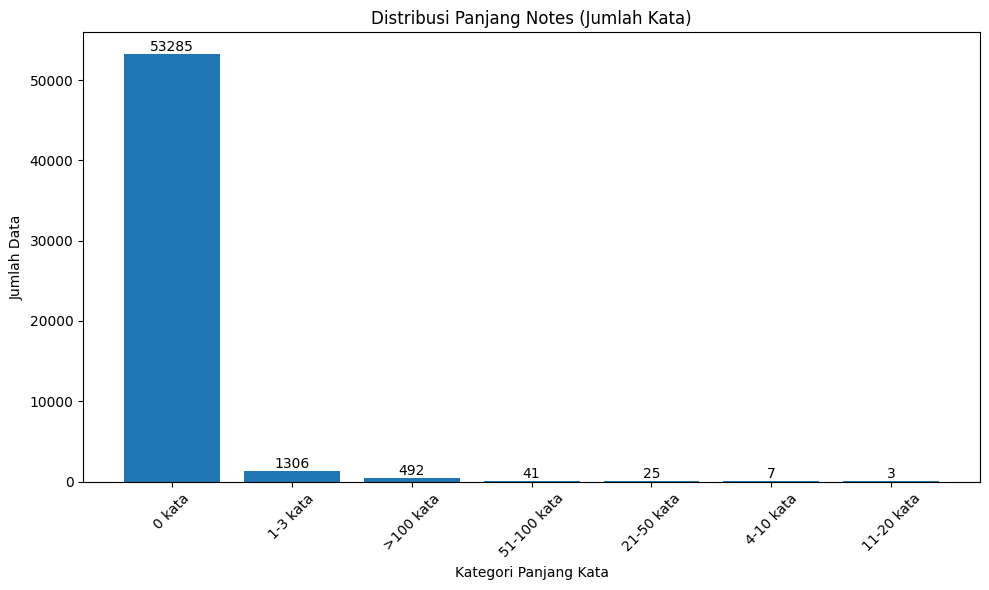

In [292]:
plt.figure(figsize=(10,6))
bars = plt.bar(upn_books['notes_word_count_category'].value_counts().index, upn_books['notes_word_count_category'].value_counts().values)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )
plt.title('Distribusi Panjang Notes (Jumlah Kata)')
plt.xlabel('Kategori Panjang Kata')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [293]:
import plotly.express as px

fig = px.histogram(
    upn_books, 
    x='notes_word_count_category', 
    title='Distribusi Panjang Kata dalam Catatan Buku',
    labels={'notes_word_count_category': 'Jumlah Kata', 'count': 'Jumlah Frekuensi'},
    color_discrete_sequence=['indianred']
)

fig.update_layout(bargap=0.1)
fig.show()


### title

#### lower

In [294]:
upn_books['title'] = upn_books['title'].fillna('')
upn_books['title'] = upn_books['title'].str.lower()

In [295]:
upn_books['title'].sample(5)

51147                    introductory statistical analysis
34151                         etika dan fisafat komunikasi
42793    ensiklopedia leadership dan manajemen muhammad...
2031     upaya diplomasi budaya tiongkok terhadap asean...
21610                 the ayatollahs and democracy in iraq
Name: title, dtype: str

In [296]:
def separate_subtitle(title):
    if ':' in title:
        main_title, sub_title = title.split(':', 1)
        return main_title.strip(), sub_title.strip()
    else:
        return title.strip(), ''

In [297]:
upn_books[['main_title', 'sub_title']] = upn_books['title'].apply(lambda x: pd.Series(separate_subtitle(x)))

In [298]:
show(upn_books[['title','main_title', 'sub_title']])

Loading ITables v2.7.0 from the internet... (need help?)


In [299]:
upn_books[upn_books['sub_title'] != ''].shape[0] / len(upn_books) * 100

30.375271936185644

#### word count

In [300]:
upn_books['title_word_count'] = upn_books['title'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
upn_books['title_word_count'].describe()

count    55160.000000
mean         8.889775
std          5.918241
min          0.000000
25%          4.000000
50%          7.000000
75%         12.000000
max         50.000000
Name: title_word_count, dtype: float64

### item code

In [301]:
def normalize_item_code(item_code):
    if pd.notna(item_code):
        item_codes = item_code.strip('<>').split('><')
        normalized_codes = [code.strip() for code in item_codes]
        return normalized_codes
    return ''

In [302]:
upn_books['item_code_normalized'] = upn_books['item_code'].apply(normalize_item_code)

In [303]:
upn_books[['item_code', 'item_code_normalized']].sample(5)

,item_code,item_code_normalized
46393,<91113601><91113602>,"[91113601, 91113602]"
14996,<609895>,[609895]
50730,<90415901><90415902><90415903><90415904>,"[90415901, 90415902, 90415903, 90415904]"
42900,<91183901><91183902><91183903>,"[91183901, 91183902, 91183903]"
39641,<823430126>,[823430126]


### authors norm

In [304]:
upn_books['authors'] = upn_books['authors'].fillna('')

In [305]:
def normalize_author_names(authors_input):
    authors_str = str(authors_input)
    authors = authors_str.strip('<>')
    authors = authors.split('><')
    
    lists = []
    first_author_last_name = None

    for group in authors:
        for name in group.split(';'):
            name = name.strip()            
            # Format: "Last, First"
            if ',' in name:
                last, first = name.split(',', 1)
                formatted_name = f"{first.strip()} {last.strip()}"
                last_name = last.strip()
            else:
                formatted_name = name
                last_name = name.split()[-1] if name else None
            lists.append(formatted_name)

            if first_author_last_name is None:
                first_author_last_name = last_name
                
    authors_clean = ', '.join(lists).title().replace("\\'", "'")
    return authors_clean, first_author_last_name


In [306]:
upn_books[['authors_norm', 'first_author_last_name']]= (upn_books['authors'].apply(lambda x: pd.Series(normalize_author_names(x))))

In [307]:
upn_books[['title', 'authors', 'authors_norm', 'first_author_last_name']].sample(5)

,title,authors,authors_norm,first_author_last_name
5641,report of the first agricultural and co-operat...,,,NaN
20464,contaminants in agriculture : exploring the so...,"<Fouda, Hazem Shawky>",Hazem Shawky Fouda,Fouda
48290,managerial accounting,"<Garrison, H.>",H. Garrison,Garrison
7859,handbook for british and irish archaeology,"<Lavell, Cherry>",Cherry Lavell,Lavell
52281,commercial fertilizers: their sources and use,"<Collings, Gilbearth H.>",Gilbearth H. Collings,Collings


In [308]:
upn_books['authors_norm'].value_counts()

authors_norm
                      2977
Nagendra Kr. Singh     253
S. S. Shashi           202
V.K. Prabhakar         101
P. C. Sinha             82
                      ... 
Anthony J. Field         1
Jeffrey L. Whitten       1
H.L. Capron              1
Robert V. Kail           1
Calvin S. Hall           1
Name: count, Length: 34269, dtype: int64

In [309]:
upn_books[upn_books['authors_norm'] == ''].sort_values('title')

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,clean_year,language_detect,notes_word_count,notes_word_count_category,main_title,sub_title,title_word_count,item_code_normalized,authors_norm,first_author_last_name
33869,,Text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,...,<NA>,Unknown,0,0 kata,,,0,,,NaN
38292,,Text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indonesia,...,<NA>,Unknown,0,0 kata,,,0,,,NaN
38567,,Text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indonesia,...,<NA>,Unknown,0,0 kata,,,0,,,NaN
42962,,Text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indonesia,...,<NA>,Unknown,0,0 kata,,,0,,,NaN
4201,'an offer you can't refuse': workfare in inter...,Electronic Resource,NaN,9781847425249,Bristol University Press (BUP),2001,379,NaN,368.44,English,...,2001,English,0,0 kata,'an offer you can't refuse',workfare in international perspective,9,[614466],,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5196,"young people, radical democracy and community ...",Electronic Resource,NaN,9781447362784,Bristol University Press (BUP),2022,258,NaN,320.40835,English,...,2022,English,0,0 kata,"young people, radical democracy and community ...",,7,[615489],,NaN
4083,youth and community empowerment in europe: int...,Electronic Resource,NaN,9781447305934,Bristol University Press (BUP),2012,224,NaN,362.71094,English,...,2012,English,0,0 kata,youth and community empowerment in europe,international perspectives,8,[614340],,NaN
38488,yurisprudensi,Text,NaN,NaN,Pengadilan Tinggi Semarang,1975,34p; 23cm,NaN,340 YUR y,Indonesia,...,1975,Indonesian,0,0 kata,yurisprudensi,,1,[07900030],,NaN
38546,yurisprudensi indonesia tentang perbuatan mela...,Text,NaN,NaN,Binacipta,1978,267p; 21cm,NaN,340 ALI y,Indonesia,...,1978,Indonesian,0,0 kata,yurisprudensi indonesia tentang perbuatan mela...,,6,[07900426],,NaN


# Riwayat

In [310]:
file_path = "data/raw/loan_history.csv"
upn_history = pd.read_csv(file_path, low_memory=False, delimiter=';')

## Data Checking

In [311]:
upn_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 5444 entries, 0 to 5443
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID Anggota         5444 non-null   int64
 1   Nama Anggota       5444 non-null   str  
 2   Kode Eksemplar     5444 non-null   int64
 3   Judul              5444 non-null   str  
 4   Tanggal Pinjam     5444 non-null   str  
 5   Tanggal Kembali    5444 non-null   str  
 6   Status peminjaman  5444 non-null   int64
dtypes: int64(3), str(4)
memory usage: 735.3 KB


In [312]:
upn_history

,ID Anggota,Nama Anggota,Kode Eksemplar,Judul,Tanggal Pinjam,Tanggal Kembali,Status peminjaman
0,196903132021211000,"Fatchullah, S.Sos, M.A",91185703,Kalkulus buku 1,2023-09-08,2023-09-15,1
1,20081010235,20081010235,91185703,Kalkulus buku 1,2023-09-08,2023-09-15,1
2,196903132021211000,"Fatchullah, S.Sos, M.A",91185703,Kalkulus buku 1,2023-09-10,2023-09-17,1
3,196903132021211000,"Fatchullah, S.Sos, M.A",90916701,Riset Operasi dan Ekonofisika (operation rese...,2023-09-11,2023-09-18,1
4,21031010224,A. Aris Syahrul Ramadhan,90007510,Komunikasi organisasi : strategi meningkatkan ...,2023-09-14,2023-09-21,1
...,...,...,...,...,...,...,...
5439,22013010294,WIDYA FRAHESTIKA,91554701,Akuntansi Keuangan Daerah Berbasis Akrual,2025-11-17,2025-11-24,0
5440,23013010026,Zidan Ardiansyah,90366601,"Pengantar ekonomi, jilid 2",2025-11-17,2025-11-24,0
5441,22012010010,KANIA LUTHFIYYAH,91028503,Bank and financial institution management conv...,2025-11-18,2025-11-25,0
5442,25013010324,ANGGUN ARTIKA DEWI,90884701,Mengenal bebrapa uji statistik dalam penelitian,2025-11-18,2025-11-25,0


kayaknya yang atas itu data trial, jadi kita cut data september

In [313]:
upn_history.isna().sum()

ID Anggota           0
Nama Anggota         0
Kode Eksemplar       0
Judul                0
Tanggal Pinjam       0
Tanggal Kembali      0
Status peminjaman    0
dtype: int64

In [314]:
upn_history.duplicated(subset=['ID Anggota','Kode Eksemplar', 'Tanggal Pinjam']).sum()

np.int64(26)

In [315]:
upn_history.duplicated().sum()

np.int64(21)

In [316]:
show(upn_history[upn_history.duplicated()].sort_index())

Loading ITables v2.7.0 from the internet... (need help?)


In [319]:
upn_history[upn_history.duplicated(subset=['ID Anggota','Kode Eksemplar', 'Tanggal Pinjam'], keep=False)].sort_values(by=['Kode Eksemplar', 'Tanggal Pinjam'])

,ID Anggota,Nama Anggota,Kode Eksemplar,Judul,Tanggal Pinjam,Tanggal Kembali,Status peminjaman
104,23043010040,RIFQI AKBAR ATHALLAH LAZUARDI,90008105,Ilmu komunikasi suatu pengantar,2023-10-09,2023-10-16,1
110,23043010040,RIFQI AKBAR ATHALLAH LAZUARDI,90008105,Ilmu komunikasi suatu pengantar,2023-10-09,2023-10-16,1
2397,24013010050,Weny Pertiwi,90732303,"Bisnis, jilid 2",2024-08-29,2024-09-05,1
2399,24013010050,Weny Pertiwi,90732303,"Bisnis, jilid 2",2024-08-29,2024-09-05,1
4426,24024010109,Titania Nova Aditia,90778704,Dasar-dasar ilmu tanah,2025-08-27,2025-08-27,1
4428,24024010109,Titania Nova Aditia,90778704,Dasar-dasar ilmu tanah,2025-08-27,2025-08-27,1
4429,24024010109,Titania Nova Aditia,90778704,Dasar-dasar ilmu tanah,2025-08-27,2025-09-03,0
8,22011010210,Sausan Kamila Zain,90888704,Ekonomika pembangunan,2023-10-02,2023-10-09,1
144,22011010210,Sausan Kamila Zain,90888704,Ekonomika pembangunan,2023-10-02,2023-10-09,1
5236,25042010166,NAZAKHA SHAFITRI,90934201,Pengantar bisnis : pengenalan praktis dan stud...,2025-10-13,2025-10-20,1


## Eksploration

### top peminjam

In [320]:
upn_history['ID Anggota'].nunique()

1827

In [321]:
users = upn_history['ID Anggota'].value_counts().reset_index()
users.columns = ['ID Anggota', 'Jumlah Pinjaman']
show(users)

Loading ITables v2.7.0 from the internet... (need help?)


In [322]:
upn_history[upn_history['ID Anggota'] == '18011010001']['Kode Eksemplar'].nunique()

0

In [359]:
upn_history[upn_history['ID Anggota'] == 18011010001]['Judul'].unique()

<ArrowStringArray>
[                                                                                                                  'Perpajakan di Indonesia',
                                                                                                         'Pajak daerah dan retribusi daerah',
                                          'Pajak Bumi dan Bangunan (PBB), Bea Perolehan Hak atas Tanah dan Bangunan (BPHTB) dan bea meterai',
                                                                                                                               'Hukum pajak',
                                                                                                           'Undang-undang Pemerintah daerah',
                                                                              'Ekonometrika : teori, konsep dan aplikasi dengan IBM SPSS 22',
                                                                                                          'Dasar-dasar ekonometri

repeat pinjem yak

### by time

In [360]:
upn_history['Tanggal Pinjam'] = pd.to_datetime(upn_history['Tanggal Pinjam'], errors='coerce')
upn_history['Tanggal Kembali'] = pd.to_datetime(upn_history['Tanggal Kembali'], errors='coerce')

In [361]:
upn_history.sample(5)

,ID Anggota,Nama Anggota,Kode Eksemplar,Judul,Tanggal Pinjam,Tanggal Kembali,Status peminjaman,tahun_pinjam,bulan_pinjam,bulan_tahun_pinjam
1394,22041010087,Fahmi Rizal Zainuri,91092205,Metode penelitian ilmu sosial : pendekatan kua...,2024-02-29,2024-03-07,0,2024,2,2024-02
2735,24083010041,Sulaiman Abhinaya Praditya,91646301,Reading financial reports for dummies,2024-09-11,2024-09-18,1,2024,9,2024-09
4172,24013010284,Franciskus Xaverius Sebastian Taufanov Esa,91136703,Etika bisnis : tuntutan dan relevansinya,2025-05-28,2025-06-04,1,2025,5,2025-05
2183,24042010300,Aulia Novika,90746703,Ilmu Sosial Dasar : mata kuliah dasar umum,2024-08-27,2024-09-03,1,2024,8,2024-08
4087,23013010026,Zidan Ardiansyah,91040502,Blue ocean strategy : strategi samudra biru,2025-04-21,2025-04-28,1,2025,4,2025-04


In [362]:
upn_history['Tanggal Pinjam'].value_counts()

Tanggal Pinjam
2025-08-27    139
2024-08-28     98
2024-08-27     84
2025-08-28     82
2023-12-18     81
             ... 
2025-08-07      1
2025-08-11      1
2025-10-18      1
2025-10-24      1
2025-10-31      1
Name: count, Length: 449, dtype: int64

In [363]:
upn_history['tahun_pinjam'] = upn_history['Tanggal Pinjam'].dt.year
upn_history['tahun_pinjam'].value_counts().sort_index()

tahun_pinjam
2023     997
2024    2496
2025    1905
Name: count, dtype: int64

#### cleans a bit

In [364]:
mask = upn_history["Tanggal Pinjam"].between("2023-09-08", "2025-11-18")
upn_history = upn_history[mask]
upn_history['tahun_pinjam'].value_counts().sort_index()


tahun_pinjam
2023     997
2024    2496
2025    1905
Name: count, dtype: int64

#### analysis

In [365]:
upn_history['bulan_pinjam'] = upn_history['Tanggal Pinjam'].dt.month
upn_history['bulan_pinjam'].value_counts().sort_index()

bulan_pinjam
1     184
2     581
3     370
4     119
5     213
6     154
7      78
8     785
9     999
10    985
11    511
12    419
Name: count, dtype: int64

In [366]:
upn_history['bulan_tahun_pinjam'] = upn_history['Tanggal Pinjam'].dt.to_period('M')
upn_history['bulan_tahun_pinjam'].value_counts().sort_index().sort_values(ascending=False)

bulan_tahun_pinjam
2024-09    527
2025-09    439
2023-10    423
2024-08    401
2025-08    384
2025-02    338
2023-12    316
2025-10    282
2024-10    280
2024-03    280
2024-02    243
2023-11    225
2024-11    208
2024-05    134
2024-01    111
2024-06    108
2024-12    103
2025-03     90
2025-05     79
2025-11     78
2025-01     73
2024-04     62
2025-04     57
2025-06     46
2024-07     39
2025-07     39
2023-09     33
Freq: M, Name: count, dtype: int64

ada outlier ternyata

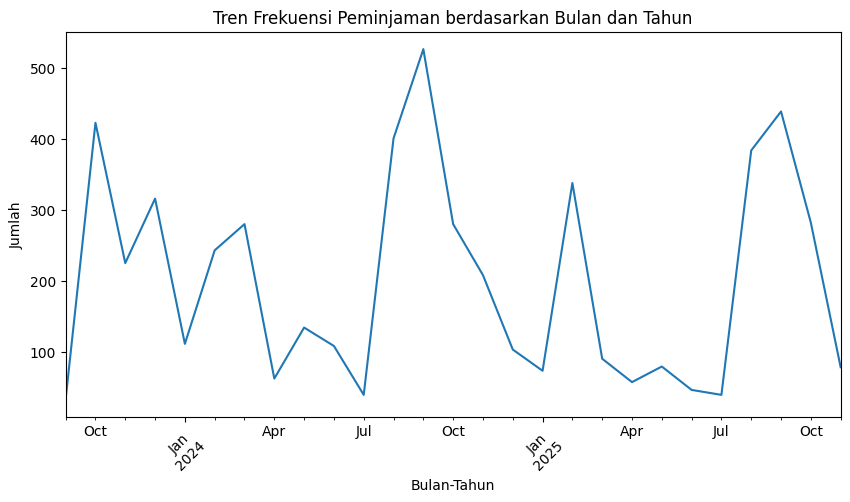

In [367]:
month_year_counts = upn_history.groupby(['bulan_tahun_pinjam']).size()
month_year_counts.index = month_year_counts.index.to_timestamp()

plt.figure(figsize=(10,5))
month_year_counts.plot()
plt.title("Tren Frekuensi Peminjaman berdasarkan Bulan dan Tahun")
plt.xlabel("Bulan-Tahun")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.show()


### cold start user

ada user yang warm banget ada yang cold banget. dengan kebanyakan data itu cold

In [368]:
loan_counts = users['Jumlah Pinjaman']

In [369]:
loan_counts.describe()

count    1827.000000
mean        2.979748
std         4.220656
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        86.000000
Name: Jumlah Pinjaman, dtype: float64

In [370]:
cold_threshold = loan_counts.quantile(0.2)
cold_threshold

np.float64(1.0)

In [371]:
loan_counts[loan_counts <= cold_threshold].shape[0]

726

In [372]:
loan_counts[loan_counts > cold_threshold].shape[0]

1101

In [373]:
loan_counts[loan_counts > loan_counts.quantile(0.9)]

0      86
1      72
2      38
3      32
4      27
       ..
137     7
138     7
139     7
140     7
141     7
Name: Jumlah Pinjaman, Length: 142, dtype: int64

In [374]:
loan_counts_frequency = loan_counts.value_counts().sort_index()
loan_counts_frequency

Jumlah Pinjaman
1     726
2     462
3     236
4     127
5      84
6      50
7      31
8      17
9      17
10     12
11     11
12      5
13      5
14      7
15      3
16      6
17      2
18      3
19      1
20      2
21      3
22      3
23      4
24      2
25      2
26      1
27      1
32      1
38      1
72      1
86      1
Name: count, dtype: int64

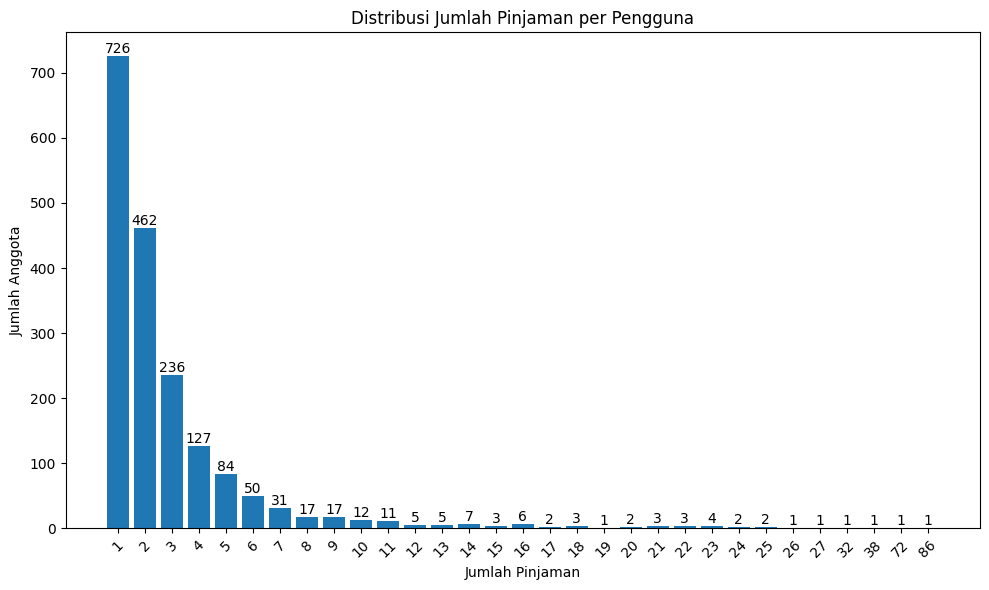

In [375]:
plt.figure(figsize=(10,6))
bars = plt.bar(loan_counts_frequency.index.astype(str), loan_counts_frequency.values)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )
plt.title('Distribusi Jumlah Pinjaman per Pengguna')
plt.xlabel('Jumlah Pinjaman')
plt.ylabel('Jumlah Anggota')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### cold item + top books

In [376]:
upn_history['Kode Eksemplar'].unique().shape[0]

3330

In [377]:
warm_item_percentage = upn_history['Kode Eksemplar'].unique().shape[0] / upn_books['item_code'].nunique() * 100
warm_item_percentage

6.27804381433581

In [378]:
books_count = upn_history['Kode Eksemplar'].value_counts()
books_count

Kode Eksemplar
91594503    13
91594502    11
90494401    11
91589901    11
91615601    10
            ..
91613201     1
90907301     1
90366601     1
90884701     1
91150201     1
Name: count, Length: 3330, dtype: int64

In [379]:
upn_history[upn_history['Kode Eksemplar'] == 91594503]

,ID Anggota,Nama Anggota,Kode Eksemplar,Judul,Tanggal Pinjam,Tanggal Kembali,Status peminjaman,tahun_pinjam,bulan_pinjam,bulan_tahun_pinjam
1195,23013010130,Dewi Putri Anggraini,91594503,Sistem Akuntansi,2024-02-07,2024-02-14,1,2024,2,2024-02
1241,23013010134,Lianda Nan Dia Putri,91594503,Sistem Akuntansi,2024-02-19,2024-02-26,1,2024,2,2024-02
1403,23013010134,Lianda Nan Dia Putri,91594503,Sistem Akuntansi,2024-03-04,2024-03-11,1,2024,3,2024-03
1500,23013010134,Lianda Nan Dia Putri,91594503,Sistem Akuntansi,2024-03-13,2024-03-20,1,2024,3,2024-03
1663,23013010133,Reri Cerarin,91594503,Sistem Akuntansi,2024-03-27,2024-04-03,1,2024,3,2024-03
1714,23013010130,Dewi Putri Anggraini,91594503,Sistem Akuntansi,2024-04-23,2024-04-30,1,2024,4,2024-04
1757,23013010134,Lianda Nan Dia Putri,91594503,Sistem Akuntansi,2024-05-08,2024-05-15,1,2024,5,2024-05
1816,23013010130,Dewi Putri Anggraini,91594503,Sistem Akuntansi,2024-05-20,2024-05-27,1,2024,5,2024-05
3663,24013010027,Jauharatul Maknuunah,91594503,Sistem Akuntansi,2025-02-10,2025-02-17,1,2025,2,2025-02
3882,24013010006,Armelia Salmarinjani,91594503,Sistem Akuntansi,2025-02-24,2025-03-03,1,2025,2,2025-02


In [380]:
books_count.describe()

count    3330.000000
mean        1.621021
std         1.234301
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        13.000000
Name: count, dtype: float64

In [381]:
book_loan_frequency = books_count.value_counts().sort_index()
book_loan_frequency

count
1     2220
2      653
3      247
4       98
5       37
6       28
7       21
8        9
9        9
10       4
11       3
13       1
Name: count, dtype: int64

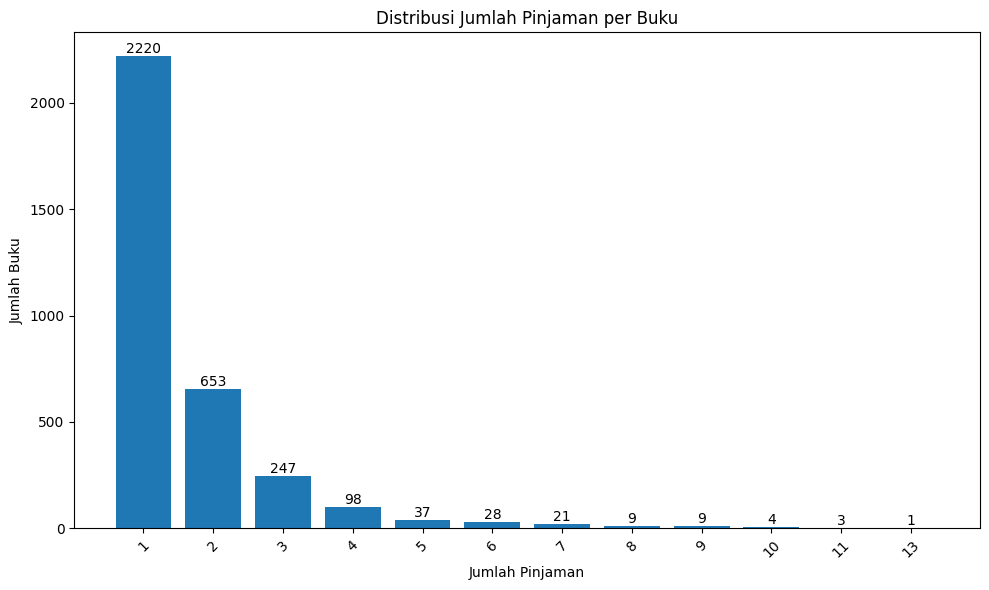

In [382]:
plt.figure(figsize=(10,6))
bars = plt.bar(book_loan_frequency.index.astype(str), book_loan_frequency.values)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )
plt.title('Distribusi Jumlah Pinjaman per Buku')
plt.xlabel('Jumlah Pinjaman')
plt.ylabel('Jumlah Buku')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [383]:
duplicate_check = upn_history.groupby('Judul')['Kode Eksemplar'].nunique().reset_index()
duplicate_check[duplicate_check['Kode Eksemplar'] > 1]

,Judul,Kode Eksemplar
9,ALGORITMA (Algoritma & Struktur Data 1) dengan...,2
13,"Administrasi Pembangunan : konsep, Dimensi, da...",3
15,Administrasi Pemerintahan Desa Di Indonesia,2
16,Administrasi Pemerintahan daerah,3
17,Administrasi Perusahaan Negara Perkembangan & ...,2
...,...,...
2033,makroekonomi,3
2039,pengelolaan ekowisata desa,2
2040,perbandingan administrasi negara,2
2041,perpajakan : teori dan Praktik,2


In [384]:
upn_history[upn_history['Judul'] == 'makroekonomi']

,ID Anggota,Nama Anggota,Kode Eksemplar,Judul,Tanggal Pinjam,Tanggal Kembali,Status peminjaman,tahun_pinjam,bulan_pinjam,bulan_tahun_pinjam
3563,21011010144,Yuda Shagy Rahmanda Putra,90404202,makroekonomi,2025-01-09,2025-01-16,1,2025,1,2025-01
3564,21011010105,Rio Ferdinand Simarmata,90890701,makroekonomi,2025-01-09,2025-01-16,1,2025,1,2025-01
3857,24024010166,Aurevita Mikaila Herdianti,90890702,makroekonomi,2025-02-19,2025-02-26,1,2025,2,2025-02
4001,24024010166,Aurevita Mikaila Herdianti,90890702,makroekonomi,2025-03-10,2025-03-17,1,2025,3,2025-03


In [385]:
upn_books[upn_books['title'] == 'makroekonomi']

,title,gmd_name,edition,isbn_issn,publisher_name,publish_year,collation,series_title,call_number,language_name,...,clean_year,language_detect,notes_word_count,notes_word_count_category,main_title,sub_title,title_word_count,item_code_normalized,authors_norm,first_author_last_name
24744,makroekonomi,Text,NaN,NaN,NaN,NaN,NaN,NaN,339 DOR m,Indonesia,...,<NA>,Indonesian,0,0 kata,makroekonomi,,1,"[90890701, 90890702]","Rudiger Dornbusch, Stanley Fischer",Dornbusch
25219,makroekonomi,Text,NaN,NaN,NaN,NaN,NaN,NaN,339 DOR m,Indonesia,...,<NA>,Indonesian,0,0 kata,makroekonomi,,1,[90404202],Rudiger Dornbusch,Dornbusch
32703,makroekonomi,Text,NaN,NaN,Erlangga,1986,"xii, 819 p.; ill.; 23 cm",NaN,339 DOR m,Indonesia,...,1986,Indonesian,0,0 kata,makroekonomi,,1,"[91072901, 91072902, 91072903]",Rudiger Dornbusch,Dornbusch
45888,makroekonomi,Text,NaN,978-979-015-436-0,Erlangga,2007,"xxxiv, 557 p.; ill.; ind.; 23 cm.",NaN,339 MAN m,Indonesia,...,2007,Indonesian,0,0 kata,makroekonomi,,1,,N. Gregory Mankiw,Mankiw
48174,makroekonomi,Text,text,979-9785-57-X,PT Media Global Edukasi,2004,"xvii, 554 p.; ill.; 26 cm.",NaN,339,Indonesia,...,2004,Indonesian,0,0 kata,makroekonomi,,1,[90404204],Rudiger Dornbusch,Dornbusch


nanti perlu reingeneering id buku supaya dia tuh instance nya nyambungnya ke id buku bukan item code. 

# Output

In [386]:
upn_books.info()

<class 'pandas.DataFrame'>
RangeIndex: 55160 entries, 0 to 55159
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   title                      55160 non-null  str     
 1   gmd_name                   55157 non-null  str     
 2   edition                    9127 non-null   str     
 3   isbn_issn                  34946 non-null  str     
 4   publisher_name             54070 non-null  str     
 5   publish_year               54253 non-null  str     
 6   collation                  42145 non-null  str     
 7   series_title               15 non-null     str     
 8   call_number                46445 non-null  str     
 9   language_name              55160 non-null  str     
 10  place_name                 33749 non-null  str     
 11  classification             32947 non-null  str     
 12  notes                      1875 non-null   str     
 13  image                      1446 non-null  

In [387]:
books_output = upn_books.copy()
history_output = upn_history.copy()

In [388]:
books_output['classification'] = books_output['classification_norm']
books_output['isbn_issn'] = books_output['isbn_issn_norm']
books_output['publish_year'] = books_output['clean_year']
books_output['authors'] = books_output['authors_norm']
books_output.drop(columns=['classification_norm', 'isbn_issn_norm', 'language_detect', 'clean_year', 'authors_norm'], inplace=True)

In [389]:
books_output['classification'].value_counts()

classification
Skripsi    10547
658          960
657          689
302.2        535
658.8        387
           ...  
643.58         1
005.422        1
004.338        1
003.5          1
005.114        1
Name: count, Length: 8197, dtype: int64

In [390]:
books_output.columns

Index(['title', 'gmd_name', 'edition', 'isbn_issn', 'publisher_name',
       'publish_year', 'collation', 'series_title', 'call_number',
       'language_name', 'place_name', 'classification', 'notes', 'image',
       'sor', 'authors', 'topics', 'item_code', 'Unnamed: 18',
       'call_number_clean', 'call_label', 'notes_word_count',
       'notes_word_count_category', 'main_title', 'sub_title',
       'title_word_count', 'item_code_normalized', 'first_author_last_name'],
      dtype='str')

In [391]:
books_output.to_csv('data/processed/books_after_understanding.csv', sep=';', index=False)

In [392]:
upn_history.info()

<class 'pandas.DataFrame'>
Index: 5398 entries, 0 to 5443
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID Anggota          5398 non-null   int64         
 1   Nama Anggota        5398 non-null   str           
 2   Kode Eksemplar      5398 non-null   int64         
 3   Judul               5398 non-null   str           
 4   Tanggal Pinjam      5398 non-null   datetime64[us]
 5   Tanggal Kembali     5398 non-null   datetime64[us]
 6   Status peminjaman   5398 non-null   int64         
 7   tahun_pinjam        5398 non-null   int32         
 8   bulan_pinjam        5398 non-null   int32         
 9   bulan_tahun_pinjam  5398 non-null   period[M]     
dtypes: datetime64[us](2), int32(2), int64(3), period[M](1), str(2)
memory usage: 751.4 KB


In [393]:
upn_history.to_csv('data/processed/trans_after_understanding.csv', sep=';', index=False)